In [47]:
import tensorflow as tf
from tensorflow.keras import layers, Model , Sequential, losses ,metrics, optimizers
from tensorflow.keras.layers import LeakyReLU, Input, Dense, LayerNormalization, Dropout,Lambda, Concatenate, Layer, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.nn import softmax
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from tensorflow.keras.callbacks import LearningRateScheduler

In [48]:
# Load dataset
TrainDataset = pd.read_csv('/kaggle/input/new-physlite/RUN2.csv', index_col=None, on_bad_lines="skip")
#TrainDataset2 = pd.read_csv('/kaggle/input/new-physlite/Top_nominal_test.csv', index_col=None, on_bad_lines="skip")
#TrainDataset = pd.read_csv('/kaggle/input/new-physlite/RUN2.csv', index_col=None, on_bad_lines="skip")
#TrainDataset = pd.concat([TrainDataset1, TrainDataset2], ignore_index=True)
TrainDataset.replace(999, 0, inplace=True)
TrainDataset.fillna(value=0, inplace=True)
TrainDataset = TrainDataset.apply(pd.to_numeric, errors='coerce').dropna()

# Define feature groups
type1_branches = ['MET_cal1_sumpt', 'jet1_pt', 'jet2_pt', 'jet3_pt', 'jet4_pt', 'photon1_pt', 'lepton1_pt', 'Large_RJet1_pt', 'HT']
type2_branches = ['jet1_phi', 'jet2_phi', 'jet3_phi', 'jet4_phi', 'photon1_phi', 'Large_RJet1_phi', 'Egamma_cluster1_calPhi']
type3_branches = ['jet1_eta', 'jet2_eta', 'jet3_eta', 'jet4_eta', 'photon1_eta', 'Large_RJet1_eta', 'Egamma_cluster1_calEta']
type4_branches = ['jet1_mass', 'jet2_mass', 'jet3_mass', 'jet4_mass','Large_RJet1_mass', 'mT', 'mj1j2', 'mj1j3', 'mj1j4', 'mj2j3', 'mj2j4', 'mj3j4']
type5_branches = ['Event_shape1_density', 'MET_cal1_e', 'MET1_sumet', 'photon1_topoetcone20', 'photon1_topoetcone40', 'Egamma_cluster1_calE']
type6_branches = [ 'delta_Rj1j2', 'delta_Rj1j3', 'delta_Rj2j3']
type7_branches = [ 'MET1_mpx', 'MET1_mpy', 'MET_cal1_py', 'MET_cal1_px', 'MET_cal1_pz']
type8_branches = ['jet1_width', 'jet2_width', 'jet3_width', 'jet4_width', 'jet1_EM_frac', 'jet2_EM_frac', 'jet3_EM_frac', 'jet4_EM_frac']
type9_branches = ['Nleptons']
type10_branches = ['nbjets']



branches = type1_branches + type2_branches + type3_branches + type4_branches + type5_branches + type6_branches + type7_branches + type8_branches + type9_branches + type10_branches

branch1_columns = [
    'photon1_topoetcone20', 'photon1_topoetcone40', 'jet1_EM_frac', 'jet2_EM_frac', 'jet3_EM_frac', 'jet4_EM_frac',
    'jet1_width', 'jet2_width', 'jet3_width', 'jet4_width', 'jet1_mass', 'jet2_mass', 'jet3_mass', 'jet4_mass',
    'MET_cal1_px', 'Egamma_cluster1_calE', 'Large_RJet1_mass'
]

# Ensure columns exist before filtering
branch1_columns = [col for col in branch1_columns if col in TrainDataset.columns]

# Correct filtering condition
if branch1_columns:
    filter_condition = np.logical_and.reduce([(TrainDataset[col] != -99) & (TrainDataset[col] != 0) for col in branch1_columns])
    TrainDataset = TrainDataset[filter_condition]

TrainDataset = TrainDataset[TrainDataset['Track1_d0'] >= -10]

# Copy filtered dataset to modify
DataSet = TrainDataset[branches]



#DataSet.loc[:, 'Scale_Jets1_pt'] = DataSet['Scale_Jets1_pt']/1000
#DataSet.loc[:, 'Scale_Jets2_pt'] = DataSet['Scale_Jets2_pt']/1000
#DataSet.loc[:, 'Scale_Jets3_pt'] = DataSet['Scale_Jets3_pt']/1000
#DataSet.loc[:, 'Scale_Jets4_pt'] = DataSet['Scale_Jets4_pt']/1000
#DataSet.loc[:, 'Scale_Jets1_mass'] = DataSet['Scale_Jets1_mass']/1000
#DataSet.loc[:, 'Scale_Jets2_mass'] = DataSet['Scale_Jets2_mass']/1000
#DataSet.loc[:, 'Scale_Jets3_mass'] = DataSet['Scale_Jets3_mass']/1000
#DataSet.loc[:, 'Scale_Jets4_mass'] = DataSet['Scale_Jets4_mass']/1000
#DataSet.loc[:, 'Track1_d0']= DataSet['Track1_d0']*100
#DataSet.loc[:, 'UFO_jet1_pt'] = DataSet['UFO_jet1_pt']/1000
#DataSet.loc[:, 'UFO_jet2_pt'] = DataSet['UFO_jet2_pt']/1000
DataSet.loc[:, 'lepton1_pt'] = DataSet['lepton1_pt']/1000
DataSet.loc[:, 'Large_RJet1_pt'] = DataSet['Large_RJet1_pt']/1000
DataSet.loc[:, 'photon1_pt'] = DataSet['photon1_pt']/1000
#DataSet.loc[:, 'photon2_pt'] = DataSet['photon2_pt']/1000
DataSet.loc[:, 'jet1_mass'] = DataSet['jet1_mass']/1000
DataSet.loc[:, 'jet2_mass'] = DataSet['jet2_mass']/1000
DataSet.loc[:, 'jet3_mass'] = DataSet['jet3_mass']/1000
DataSet.loc[:, 'jet4_mass'] = DataSet['jet4_mass']/1000
DataSet.loc[:, 'jet1_pt'] = DataSet['jet1_pt']/1000
DataSet.loc[:, 'jet2_pt'] = DataSet['jet2_pt']/1000
DataSet.loc[:, 'jet3_pt'] = DataSet['jet3_pt']/1000
DataSet.loc[:, 'jet4_pt'] = DataSet['jet4_pt']/1000
#DataSet.loc[:, 'UFO_jet1_mass'] = DataSet['UFO_jet1_mass']/1000
#DataSet.loc[:, 'UFO_jet2_mass'] = DataSet['UFO_jet2_mass']/1000
DataSet.loc[:, 'Large_RJet1_mass'] = DataSet['Large_RJet1_mass']/1000
DataSet.loc[:, 'MET_cal1_sumpt']=DataSet['MET_cal1_sumpt']/1000
#DataSet.loc[:, 'MET_cal2_sumpt']=DataSet['MET_cal2_sumpt']/1000
DataSet.loc[:, 'MET_cal1_px']=DataSet['MET_cal1_px']/10000
DataSet.loc[:, 'MET_cal1_py']=DataSet['MET_cal1_py']/10000
DataSet.loc[:, 'MET_cal1_pz']=DataSet['MET_cal1_pz']/10000
#DataSet.loc[:, 'MET_cal2_px']=DataSet['MET_cal2_px']/10000
#DataSet.loc[:, 'MET_cal2_py']=DataSet['MET_cal2_py']/10000
#DataSet.loc[:, 'MET_cal2_pz']=DataSet['MET_cal2_pz']/10000
DataSet.loc[:, 'MET1_mpx']=DataSet['MET1_mpx']/1000
DataSet.loc[:, 'MET1_mpy']=DataSet['MET1_mpy']/1000
DataSet.loc[:, 'jet1_width']=DataSet['jet1_width']*100
DataSet.loc[:, 'jet2_width']=DataSet['jet2_width']*100
DataSet.loc[:, 'jet3_width']=DataSet['jet3_width']*100
DataSet.loc[:, 'jet4_width']=DataSet['jet4_width']*100
DataSet.loc[:, 'jet1_EM_frac']=DataSet['jet1_EM_frac']*10
DataSet.loc[:, 'jet2_EM_frac']=DataSet['jet2_EM_frac']*10
DataSet.loc[:, 'jet3_EM_frac']=DataSet['jet3_EM_frac']*10
DataSet.loc[:, 'jet4_EM_frac']=DataSet['jet4_EM_frac']*10
#DataSet.loc[:, 'Track1_qOverP']=DataSet['Track1_qOverP']*10000
#DataSet.loc[:, 'Large_RJet1_Tau1_wta']=DataSet['Large_RJet1_Tau1_wta']*10
#DataSet.loc[:, 'Large_RJet1_Tau2_wta']=DataSet['Large_RJet1_Tau2_wta']*10
DataSet.loc[:, 'Event_shape1_density'] = DataSet['Event_shape1_density']/1000
DataSet.loc[:, 'photon1_topoetcone20'] = DataSet['photon1_topoetcone20']/1000
DataSet.loc[:, 'photon1_topoetcone40'] = DataSet['photon1_topoetcone40']/1000
#DataSet.loc[:, 'photon2_topoetcone20'] = DataSet['photon2_topoetcone20']/1000
#DataSet.loc[:, 'photon2_topoetcone40'] = DataSet['photon2_topoetcone40']/1000
DataSet.loc[:, 'MET_cal1_e']=DataSet['MET_cal1_e']/1000
#DataSet.loc[:, 'MET_cal2_e']=DataSet['MET_cal2_e']/1000
DataSet.loc[:, 'Egamma_cluster1_calE']=DataSet['Egamma_cluster1_calE']/1000
DataSet.loc[:, 'MET1_sumet'] = DataSet['MET1_sumet']/1000
#DataSet.loc[:, 'pT']=DataSet['pT']/100000
DataSet.loc[:, 'HT']=DataSet['HT']/10000
DataSet.loc[:, 'mT']=DataSet['mT']/10000
DataSet.loc[:, 'mj1j2']=DataSet['mj1j2']/10000
DataSet.loc[:, 'mj1j3']=DataSet['mj1j3']/10000
DataSet.loc[:, 'mj1j4']=DataSet['mj1j4']/10000
DataSet.loc[:, 'mj2j3']=DataSet['mj2j3']/10000
DataSet.loc[:, 'mj2j4']=DataSet['mj2j4']/10000
DataSet.loc[:, 'mj3j4']=DataSet['mj3j4']/10000
DataSet.loc[:, 'nbjets']=DataSet['nbjets']*10
DataSet.loc[:, 'Nleptons']=DataSet['Nleptons']*10

#DataSet.replace(-0.099000, 0, inplace=True)
#DataSet.replace(-99, 0, inplace=True)



X_train, X_val = train_test_split(DataSet, test_size=0.1, random_state=123)


type4_branches
def separate_columns(X_train, X_val, columns):
    X_train_sep = X_train[columns].to_numpy()[:, np.newaxis]
    X_val_sep = X_val[columns].to_numpy()[:, np.newaxis]
    return X_train_sep, X_val_sep

# Separate each group
X_train_type1, X_val_type1 = separate_columns(X_train, X_val, type1_branches)
X_train_type2, X_val_type2 = separate_columns(X_train, X_val, type2_branches)
X_train_type3, X_val_type3 = separate_columns(X_train, X_val, type3_branches)
X_train_type4, X_val_type4 = separate_columns(X_train, X_val, type4_branches)
X_train_type5, X_val_type5 = separate_columns(X_train, X_val, type5_branches)
X_train_type6, X_val_type6 = separate_columns(X_train, X_val, type6_branches)
X_train_type7, X_val_type7 = separate_columns(X_train, X_val, type7_branches)
X_train_type8, X_val_type8 = separate_columns(X_train, X_val, type8_branches)
X_train_type9, X_val_type9 = separate_columns(X_train, X_val, type9_branches)
X_train_type10, X_val_type10 = separate_columns(X_train, X_val, type10_branches)



X_train_, X_val_ = separate_columns(X_train, X_val, branches)
print (DataSet.shape[0])


/tmp/ipykernel_78/615934855.py:2: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  TrainDataset = pd.read_csv('/kaggle/input/new-physlite/RUN2.csv', index_col=None, on_bad_lines="skip")


773293


In [49]:
TrainDataset

,MET_cal1_px,MET_cal1_py,MET_cal1_pz,MET_cal1_e,MET_cal1_sumpt,MET_cal2_px,MET_cal2_py,MET_cal2_pz,MET_cal2_e,MET_cal2_sumpt,...,lepton1_eta,lepton2_pt,lepton2_phi,lepton2_eta,lepton3_pt,lepton3_phi,lepton3_eta,lepton4_pt,lepton4_phi,lepton4_eta
6,11180.994141,73826.757812,346111.906250,354118.750000,74717.367188,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,...,-99.000000,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0
9,50975.664062,87796.296875,183540.500000,209794.515625,101599.500000,-1937.060059,-4668.087402,889.918579,5131.783203,5054.032227,...,-99.000000,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0
11,-615.914429,3164.258545,6552.755859,7302.772949,3223.644287,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,...,1.457507,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0
12,12340.755859,-11181.380859,-21487.861328,27185.394531,16652.853516,2286.565186,-420.511658,-2691.735840,3556.775391,2324.910889,...,-1.078141,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0
15,-19432.125000,25485.144531,-99200.476562,104299.851562,32190.044922,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,...,-99.000000,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2309793,7761.549805,-12157.516602,-41883.066406,44326.710938,14450.289062,-707.493713,2897.653564,-3644.574219,4709.550293,2982.774414,...,-99.000000,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0
2309796,-3370.100586,-1374.954224,-8793.615234,9517.128906,3639.790771,-1303.426025,-4378.502930,15889.374023,16533.070312,4568.392090,...,-99.000000,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0
2309797,86475.398438,-61354.261719,-404858.781250,418570.718750,106162.234375,-99.000000,-99.000000,-99.000000,-99.000000,-99.000000,...,1.682935,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0
2309800,-24936.205078,-36172.535156,-206019.078125,210657.593750,43935.625000,38878.457031,-3471.919434,-50605.718750,63956.406250,39089.324219,...,-99.000000,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0


In [50]:
DataSet

,MET_cal1_sumpt,jet1_pt,jet2_pt,jet3_pt,jet4_pt,photon1_pt,lepton1_pt,Large_RJet1_pt,HT,jet1_phi,...,jet1_width,jet2_width,jet3_width,jet4_width,jet1_EM_frac,jet2_EM_frac,jet3_EM_frac,jet4_EM_frac,Nleptons,nbjets
6,74.717367,83.171531,49.009770,31.419662,28.349184,3.473748,-0.099000,112.542273,23.294155,1.425493,...,6.180092,12.549421,7.129159,9.647763,4.540288,2.336804,6.671775,9.273940,0.0,0.0
9,101.599500,129.683750,140.244594,78.949906,56.612785,9.607888,-0.099000,194.696687,56.872281,-1.846650,...,12.373387,5.396434,12.099441,7.692777,3.429193,4.532831,7.767280,6.046993,0.0,0.0
11,3.223644,188.347234,164.707922,52.313445,13.517937,3.700320,4.929452,227.420828,47.092330,-1.275101,...,12.145812,8.057309,16.650201,9.428242,2.327912,6.130445,7.162080,2.239927,10.0,10.0
12,16.652854,144.350516,63.311434,25.819477,24.397654,4.098791,18.935373,156.550672,31.660217,2.647470,...,12.684400,11.715465,9.496654,12.312487,4.336583,2.308599,8.628551,0.815112,10.0,0.0
15,32.190045,176.801141,74.753156,52.851672,27.383334,2.169873,-0.099000,173.132703,39.667299,-0.830557,...,7.263381,14.777616,14.388566,5.467951,5.568519,3.676983,6.314825,0.188362,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2309793,14.450289,169.725844,119.351086,59.626844,41.409687,77.927359,-0.099000,186.495375,54.935176,2.340511,...,13.925195,3.163731,10.284203,5.769145,3.292223,8.605599,6.572818,3.127123,0.0,0.0
2309796,3.639791,134.828797,105.433039,17.295840,15.104022,4.815843,-0.099000,164.821625,28.155552,1.134375,...,11.929100,17.009944,13.216862,10.912233,2.094805,4.986738,3.956280,3.266308,0.0,0.0
2309797,106.162234,113.693141,121.112109,48.295234,29.864867,3.978735,2.738677,141.179406,39.090864,-0.618493,...,5.487251,11.333845,11.339165,11.737709,3.706181,3.167095,6.693794,10.017400,10.0,0.0
2309800,43.935625,76.242523,51.732930,50.561875,35.024938,4.117863,-0.099000,117.380727,32.168428,2.214818,...,10.202044,5.200597,8.177908,9.511574,0.993748,6.520926,3.796035,4.907514,0.0,0.0


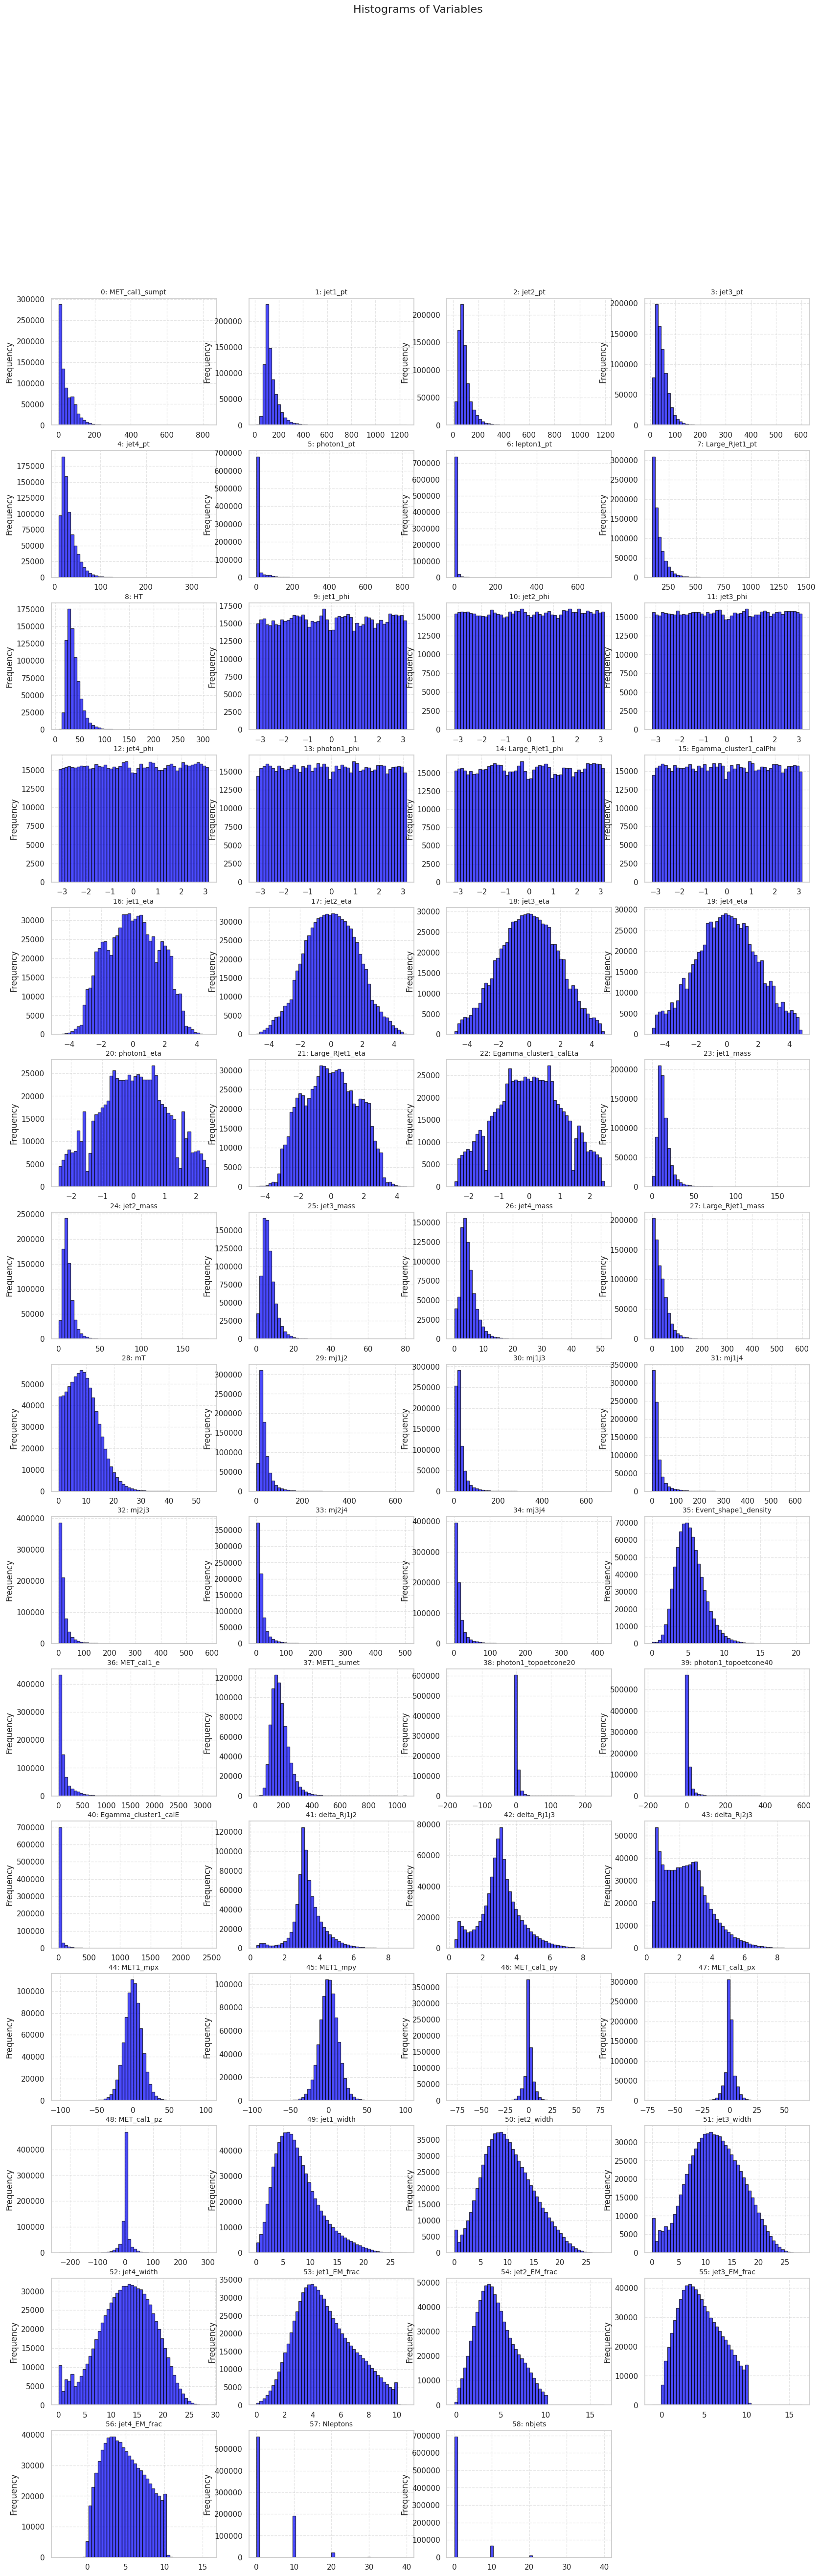

In [51]:
import matplotlib.pyplot as plt
import numpy as np

# Set the number of columns for subplots
num_cols = 4
num_vars = len(branches)
num_rows = int(np.ceil(num_vars / num_cols))

fig, axes = plt.subplots(num_rows, num_cols, figsize=(20, 4 * num_rows))
fig.suptitle("Histograms of Variables", fontsize=16)

# Flatten the axes array for easy iteration
axes = axes.flatten()

# Plot histograms
for i, var in enumerate(branches):
    ax = axes[i]
    ax.hist(DataSet[var], bins=50, color='blue', alpha=0.7, edgecolor='black')
    ax.set_title(f"{i}: {var}", fontsize=10)
    #ax.set_xlabel("")
    ax.set_ylabel("Frequency")
    ax.grid(True, linestyle='--', alpha=0.5)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

#plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [52]:
# Custom Layer Normalization
class CustomLayerNormalization(layers.Layer):
    def __init__(self, epsilon=1e-6):
        super(CustomLayerNormalization, self).__init__()
        self.epsilon = epsilon

    def build(self, input_shape):
        self.gamma = self.add_weight(shape=(input_shape[-1],), initializer="ones", trainable=True)
        self.beta = self.add_weight(shape=(input_shape[-1],), initializer="zeros", trainable=True)

    def call(self, inputs):
        mean = tf.reduce_mean(inputs, axis=-1, keepdims=True)
        variance = tf.reduce_mean(tf.square(inputs - mean), axis=-1, keepdims=True)
        normalized = (inputs - mean) / tf.sqrt(variance + self.epsilon)
        return self.gamma * normalized + self.beta


# Custom Linear Layer with Weight Decay
class CustomLinear(layers.Layer):
    def __init__(self, out_features, weight_decay=0.00001):
        super(CustomLinear, self).__init__()
        self.out_features = out_features
        self.weight_decay = weight_decay

    def build(self, input_shape):
        self.weight = self.add_weight(shape=(input_shape[-1], self.out_features),
                                      initializer="random_normal",
                                      regularizer=tf.keras.regularizers.l2(self.weight_decay),
                                      trainable=True)
        self.bias = self.add_weight(shape=(self.out_features,), initializer="zeros", trainable=True)

    def call(self, inputs):
        return tf.matmul(inputs, self.weight) + self.bias


# Advanced Feed Forward Layer
class AdvancedFeedForward(layers.Layer):
    def __init__(self, dff, d_model, rate, weight_decay, alpha_rt):
        super(AdvancedFeedForward, self).__init__()
        self.dense1 = CustomLinear(dff, weight_decay)
        self.dense2 = CustomLinear(d_model, weight_decay)
        self.dropout = layers.Dropout(rate)
        self.layernorm = layers.BatchNormalization()
        self.alpha_rt = alpha_rt

    def call(self, x, training):
        x = self.dense1(x)
        x = tf.nn.leaky_relu(x, alpha=self.alpha_rt)
        x = self.dropout(x, training=training)
        x = self.dense2(x)
        return self.layernorm(x + self.dropout(x, training=training))


# Multi-Head Attention Layer
class MultiHeadAttention(layers.Layer):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        assert d_model % self.num_heads == 0
        self.depth = d_model // self.num_heads
        self.wq = layers.Dense(d_model)
        self.wk = layers.Dense(d_model)
        self.wv = layers.Dense(d_model)
        self.dense = layers.Dense(d_model)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def scaled_dot_product_attention(self, q, k, v, mask=None):
        matmul_qk = tf.matmul(q, k, transpose_b=True)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)
        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        output = tf.matmul(attention_weights, v)
        return output, attention_weights

    def call(self, q, k, v, mask=None):
        batch_size = tf.shape(q)[0]
        q = self.split_heads(self.wq(q), batch_size)
        k = self.split_heads(self.wk(k), batch_size)
        v = self.split_heads(self.wv(v), batch_size)
        scaled_attention, attention_weights = self.scaled_dot_product_attention(q, k, v, mask)
        scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(scaled_attention, (batch_size, -1, self.d_model))
        return self.dense(concat_attention), attention_weights


# Transformer Block
class TransformerBlock(layers.Layer):
    def __init__(self, d_model, num_heads, dff, rate, weight_decay, alpha_rt):
        super(TransformerBlock, self).__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = AdvancedFeedForward(dff, d_model, rate, weight_decay, alpha_rt)
        self.layernorm1 = layers.BatchNormalization(epsilon=1e-6)
        self.layernorm2 = layers.BatchNormalization(epsilon=1e-6)
        self.dropout1 = layers.Dropout(rate)
        self.dropout2 = layers.Dropout(rate)

    def call(self, x, training, mask=None):
        attn_output, attention_weights = self.mha(x, x, x, mask=mask)
        out1 = self.layernorm1(x + self.dropout1(attn_output))
        ffn_output = self.ffn(out1, training=training)
        out2 = self.layernorm2(out1 + self.dropout1(ffn_output))
        return out2, attention_weights


# Transformer Encoder
class TransformerEncoder(layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, rate, weight_decay, alpha_rt):
        super(TransformerEncoder, self).__init__()
        self.num_layers = num_layers
        self.enc_layers = [TransformerBlock(d_model, num_heads, dff, rate, weight_decay, alpha_rt) for _ in range(num_layers)]

    def call(self, x, training=None, mask=None):
        attention_weights_all_layers = []
        for i in range(self.num_layers):
            x, attention_weights = self.enc_layers[i](x, training=training)
            attention_weights_all_layers.append(attention_weights)
        return x, attention_weights_all_layers


# Transformer Decoder
class TransformerDecoder(layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, rate, weight_decay, alpha_rt):
        super(TransformerDecoder, self).__init__()
        self.num_layers = num_layers
        self.dec_layers = [TransformerBlock(d_model, num_heads, dff, rate, weight_decay, alpha_rt) for _ in range(num_layers)]

    def call(self, x, enc_output, training=None, mask=None):
        attention_weights_all_layers = []
        for i in range(self.num_layers):
            x, attention_weights = self.dec_layers[i](x, training=training)
            attention_weights_all_layers.append(attention_weights)
        return x, attention_weights_all_layers


# Transformer Model
class Transformer(Model):
    def __init__(self, num_encoder_layers, num_decoder_layers, input_dim, d_model, num_heads, dff, rate, weight_decay, alpha_rt):
        super(Transformer, self).__init__()
        self.encoder = TransformerEncoder(num_encoder_layers, d_model, num_heads, dff, rate, weight_decay, alpha_rt)
        self.decoder = TransformerDecoder(num_decoder_layers, d_model, num_heads, dff, rate, weight_decay, alpha_rt)
        self.final_layer = layers.Dense(input_dim)
        self.d_model = d_model
        self.input1_embedding = tf.keras.layers.Dense(32)
        self.input2_embedding = tf.keras.layers.Dense(32)
        self.input3_embedding = tf.keras.layers.Dense(32)
        self.input4_embedding = tf.keras.layers.Dense(32)
        self.input5_embedding = tf.keras.layers.Dense(32)
        self.input6_embedding = tf.keras.layers.Dense(8)
        self.input7_embedding = tf.keras.layers.Dense(32)
        self.input8_embedding = tf.keras.layers.Dense(32)

        self.discrete_output_1 = tf.keras.layers.Dense(1, activation='linear')
        self.discrete_output_2 = tf.keras.layers.Dense(1, activation='linear')
        
        self.output1 = tf.keras.layers.Dense(9,activation='linear')  # Output for continuous features
        self.output2 = tf.keras.layers.Dense(7,activation='linear')  # Output for continuous features
        self.output3 = tf.keras.layers.Dense(7,activation='linear')  # Output for continuous features
        self.output4 = tf.keras.layers.Dense(12,activation='linear')  # Output for continuous features
        self.output5 = tf.keras.layers.Dense(6,activation='linear')  # Output for continuous features
        self.output6 = tf.keras.layers.Dense(3,activation='linear')  # Output for continuous features
        self.output7 = tf.keras.layers.Dense(5,activation='linear')  # Output for continuous features
        self.output8 = tf.keras.layers.Dense(8,activation=  tf.keras.layers.LeakyReLU(alpha=0.1))  # Output for continuous features
        
        self.width1_output = tf.keras.layers.Dense(1)#,activation='sigmoid')  # Output for continuous features
        self.width2_output = tf.keras.layers.Dense(1)#,activation='sigmoid')
        self.width3_output = tf.keras.layers.Dense(1)#,activation='sigmoid')
        self.width4_output = tf.keras.layers.Dense(1)#,activation='sigmoid')


    def get_config(self):
        config = super(Transformer, self).get_config()
        config.update({
            'num_encoder_layers': self.encoder.num_layers,
            'num_decoder_layers': self.decoder.num_layers,
            'd_model': self.d_model,
            'num_heads': self.encoder.enc_layers[0].mha.num_heads,
            'dff': self.encoder.enc_layers[0].ffn.dense1.out_features,
            'input_dim': self.final_layer.units,
            'rate': self.encoder.enc_layers[0].ffn.dropout.rate,
            'weight_decay': self.encoder.enc_layers[0].ffn.dense1.weight_decay,
            'alpha_rt': self.encoder.enc_layers[0].ffn.alpha_rt, # Get alpha_rt from AdvancedFeedForward
        })
        return config

    @classmethod
    def from_config(cls, config, custom_objects=None):
        # Extract and remove Keras-specific attributes before passing to __init__
        return cls(
            num_encoder_layers=config['num_encoder_layers'],
            num_decoder_layers=config['num_decoder_layers'],
            d_model=config['d_model'],
            num_heads=config['num_heads'],
            dff=config['dff'],
            input_dim=config['input_dim'],
            rate=config['rate'],
            weight_decay=config['weight_decay'],
            alpha_rt=config['alpha_rt']
        )

    def call(self, inputs, training=None):
        input1,input2,input3,input4, input5, input6, input7, input8,dict1,dict2= inputs
        dict1 = tf.cast(dict1, dtype=tf.float32)
        dict2 = tf.cast(dict2, dtype=tf.float32)

        input1_embd= self.input1_embedding(input1)
        input2_embd= self.input2_embedding(input2)
        input3_embd= self.input3_embedding(input3)
        input4_embd= self.input4_embedding(input4)
        input5_embd= self.input5_embedding(input5)
        input6_embd= self.input6_embedding(input6)
        input7_embd= self.input7_embedding(input7)
        input8_embd= self.input8_embedding(input8)

        #dict1_embd = self.dict1_embedding(dict1)
        #dict2_embd = self.dict2_embedding(dict2)
        #dict1_embd = tf.squeeze(dict1_embd, axis=1)
        #dict2_embd = tf.squeeze(dict2_embd, axis=1)
        dict1_embd = dict1
        dict2_embd = dict2

        enc_input = tf.concat([input1_embd,input2_embd,input3_embd,input4_embd, input5_embd, input6_embd, input7_embd, input8_embd, dict1_embd, dict2_embd], axis=-1)



        enc_output, encoder_attention_weights = self.encoder(enc_input, training=training)
        dec_input = enc_input
        final_output, _ = self.decoder(dec_input, enc_output, training=training)
        final_output = self.final_layer(final_output)
        type1_output = self.output1(final_output)
        type2_output = self.output2(final_output)
        type3_output = self.output3(final_output)
        type4_output = self.output4(final_output)
        type5_output = self.output5(final_output)
        type6_output = self.output6(final_output)
        type7_output = self.output7(final_output)
        type8_output = self.output8(final_output)
        dict1_output = self.discrete_output_1(final_output)
        dict2_output = self.discrete_output_2(final_output)

        output = tf.concat([type1_output, type2_output, type3_output, type4_output, type5_output, type6_output, type7_output, type8_output, dict1_output, dict2_output], axis=-1)
        return output


class LossHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs={}):
        self.losses = []
        self.val_losses = []

    def on_epoch_end(self, batch, logs={}):
        self.losses.append(logs.get('loss'))
        self.val_losses.append(logs.get('val_loss'))

    def save_losses(self, file_path):
        with open(file_path, 'w') as file:
            json.dump({'losses': self.losses, 'val_losses': self.val_losses}, file)

    def load_losses(self, file_path):
        with open(file_path, 'r') as file:
            data = json.load(file)
            self.losses = data['losses']
            self.val_losses = data['val_losses']
loss_history = LossHistory()


class EarlyStopping(tf.keras.callbacks.Callback):
    def __init__(self, patience=5, min_delta=0):
        super(EarlyStopping, self).__init__()
        self.patience = patience
        self.min_delta = min_delta
        self.counter = 0
        self.best_loss = None
        self.best_weights = None

    def on_epoch_end(self, epoch, logs=None):
        current_loss = logs.get("val_loss")
        if self.best_loss is None:
            self.best_loss = current_loss
            self.best_weights = self.model.get_weights()  # Save weights
        elif self.best_loss - current_loss > self.min_delta:
            self.best_loss = current_loss
            self.best_weights = self.model.get_weights()  # Save new best weights
            self.counter = 0
        else:
            self.counter += 1
            print(f"INFO: Early stopping counter {self.counter} of {self.patience}")
            if self.counter >= self.patience:
                print('INFO: Early stopping')
                self.model.stop_training = True
                self.model.set_weights(self.best_weights)  # Restore best weights




import tensorflow as tf

class CustomWeightedLoss(tf.keras.losses.Loss):
    def __init__(self, weight_loss, num_discrete_vars=2, **kwargs):
        super(CustomWeightedLoss, self).__init__(**kwargs)
        self.weight_loss = tf.convert_to_tensor(weight_loss, dtype=tf.float32)  # Weights for all variables
        self.num_discrete_vars = num_discrete_vars  # Last `num_discrete_vars` are discrete

    def call(self, y_true, y_pred):
        # Number of continuous variables
        num_continuous_vars = tf.shape(y_true)[-1] - self.num_discrete_vars

        # Split continuous and discrete variables
        y_true_cont, y_true_disc = y_true[..., :num_continuous_vars], y_true[..., -self.num_discrete_vars:]
        y_pred_cont, y_pred_disc = y_pred[..., :num_continuous_vars], y_pred[..., -self.num_discrete_vars:]

        # Split weights for MAE and MSE
        weight_mae = self.weight_loss[:num_continuous_vars]  # First part for MAE
        weight_mse = self.weight_loss[-self.num_discrete_vars:]  # Last two for MSE

        # Compute Weighted MAE for continuous variables
        mae = tf.abs(y_true_cont - y_pred_cont)
        weighted_mae = tf.multiply(mae, weight_mae)

        # Compute Weighted MSE for discrete variables
        mse = tf.square(y_true_disc - y_pred_disc)
        weighted_mse = tf.multiply(mse, weight_mse)

        # Combine both losses
        total_loss = tf.reduce_mean(weighted_mae) + 0.1*tf.reduce_mean(weighted_mse)
        return total_loss

    def get_config(self):
        config = super(CustomWeightedLoss, self).get_config()
        config.update({
            'weight_loss': self.weight_loss.numpy().tolist(),
            'num_discrete_vars': self.num_discrete_vars
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(
            weight_loss=tf.convert_to_tensor(config['weight_loss'], dtype=tf.float32),
            num_discrete_vars=config['num_discrete_vars']
        )


In [53]:
input_dim=len(branches)
weight_loss= [1]*len(branches)
"""
weight_loss=[  ]

"""
"""weight_loss = [
    1, 1, 5, 5, 5, 5, 5, 1, 1, 5,
    5, 5, 5, 5, 5, 5, 5,
    5, 5, 5, 5, 5, 1, 5,
    1, 5, 1, 1, 5, 5, 5, 5, 5, 5, 5,
    5, 5, 5, 5, 5, 5,
    5, 5, 1,
    5, 5, 5, 5, 1, 5,
    1, 5, 1, 1, 1, 1, 5, 1, 5, 5,
    5, 5
]"""


model = Transformer(num_encoder_layers=6, num_decoder_layers=6, input_dim=input_dim, d_model=234, num_heads=6, dff=1024, rate=0.3, weight_decay=1e-4, alpha_rt=0.05)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),loss= CustomWeightedLoss(weight_loss))# CustomWeightedMAELoss(weight_loss))

def scheduler(epoch):
    if epoch < 10:
        return 1e-3
    elif epoch < 20:
        return 1e-4
    elif epoch < 30:
        return 1e-5  # should continue decreasing
    else:
        return 5e-6  # even smaller after 50

lr_scheduler = tf.keras.callbacks.LearningRateScheduler(scheduler)


# Train the model
history = model.fit(
    (X_train_type1,X_train_type2,X_train_type3,X_train_type4,X_train_type5,X_train_type6,X_train_type7,X_train_type8,X_train_type9,X_train_type10  ),X_train_,
    epochs=50,batch_size=512,verbose=1,
    validation_data=((X_val_type1,X_val_type2,X_val_type3,X_val_type4, X_val_type5, X_val_type6, X_val_type7,X_val_type8,X_val_type9,X_val_type10 ),X_val_,),
    callbacks=[ lr_scheduler, loss_history,EarlyStopping()]
)

/usr/local/lib/python3.11/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/layer.py:393: UserWarning: `build()` was called on layer 'transformer_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/keras/src/optimizers/base_optimizer.py:774: UserWarning: Gradients do not exist for variables ['transformer_1/transformer_encoder_1/transformer_block_12/multi_head_attention_12/dense_71/kernel', 'transformer_1/transformer_encoder_1/transformer_block_12/multi_head_attention_12/dense_71/bias', 'transformer_1/transformer_encoder_1/transformer_block_12/multi_head_attention_12/dense_72/kernel', 'transformer_1/transformer_encoder_1/transformer_block_12/multi_head_attention_12/dense_72/bias', 'transformer_1/transformer_encoder_1/transfor

1360/1360 ━━━━━━━━━━━━━━━━━━━━ 179s 57ms/step - loss: 13.4847 - val_loss: 6.8020 - learning_rate: 0.0010
Epoch 2/50
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 38s 28ms/step - loss: 5.6528 - val_loss: 4.0443 - learning_rate: 0.0010
Epoch 3/50
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 38s 28ms/step - loss: 2.8218 - val_loss: 1.1506 - learning_rate: 0.0010
Epoch 4/50
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 37s 27ms/step - loss: 1.4472 - val_loss: 0.8151 - learning_rate: 0.0010
Epoch 5/50
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 37s 27ms/step - loss: 1.1393 - val_loss: 0.6711 - learning_rate: 0.0010
Epoch 6/50
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 37s 27ms/step - loss: 1.0231 - val_loss: 0.5585 - learning_rate: 0.0010
Epoch 7/50
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 37s 27ms/step - loss: 0.9781 - val_loss: 0.4575 - learning_rate: 0.0010
Epoch 8/50
1358/1360 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.9451INFO: Early stopping counter 1 of 5
1360/1360 ━━━━━━━━━━━━━━━━━━━━ 37s 27ms/step - loss: 0.9451 - val_loss: 0.5575 - learning_rate: 0.0010
Epo

In [54]:
from re import X
import pandas as pd
import tensorflow as tf

#weight_loss = [1,1,1]

def RecoProb_(Y_true, Y_pred, weight_loss):
    N = 0
    nll_loss = 0
    ml_weights = weight_loss
    Y_true = Y_true
    for ix, wi in enumerate(ml_weights):
        y_pred = Y_pred[:, ix:ix + 1]
        y_true = Y_true[:, ix:ix + 1]
        single_NLL = tf.abs(y_true - y_pred)
        nll_loss += tf.reduce_mean(wi * single_NLL, axis=-1)

    return nll_loss


def process_file(filepath):
    # Read the CSV file
    Dataset = pd.read_csv(filepath, index_col=None, on_bad_lines='skip')
    Dataset_=Dataset
    #weight_loss = [1] * len(branches)

    Dataset.replace(999, 0, inplace=True)
    Dataset.fillna(-99, inplace=True)

    Dataset = Dataset.apply(pd.to_numeric, errors='coerce').dropna()
    #Dataset = Dataset.dropna().loc[~Dataset.applymap(lambda x: isinstance(x, str)).any(axis=1)]

    
    filter_condition = np.logical_and.reduce([(Dataset[col] != -99) & (Dataset[col] != 0) for col in branch1_columns])
    Dataset = Dataset[filter_condition]
    #Dataset = Dataset[Dataset['Track1_d0'] >= -10]
    # Copy filtered dataset to modify
    X_test = Dataset[branches][:20000]
    dataset = Dataset[:20000]


    #X_test.loc[:, 'Scale_Jets1_pt'] =     X_test['Scale_Jets1_pt']/1000
    #X_test.loc[:, 'Scale_Jets2_pt'] =     X_test['Scale_Jets2_pt']/1000
    #X_test.loc[:, 'Scale_Jets3_pt'] =     X_test['Scale_Jets3_pt']/1000
    #X_test.loc[:, 'Scale_Jets4_pt'] =     X_test['Scale_Jets4_pt']/1000
    #X_test.loc[:, 'Scale_Jets1_mass'] =     X_test['Scale_Jets1_mass']/1000
    #X_test.loc[:, 'Scale_Jets2_mass'] =     X_test['Scale_Jets2_mass']/1000
    #X_test.loc[:, 'Scale_Jets3_mass'] =     X_test['Scale_Jets3_mass']/1000
    #X_test.loc[:, 'Scale_Jets4_mass'] =     X_test['Scale_Jets4_mass']/1000
    #X_test.loc[:, 'Track1_d0']=     X_test['Track1_d0']*100
    #X_test.loc[:, 'UFO_jet1_pt'] =     X_test['UFO_jet1_pt']/1000
    #X_test.loc[:, 'UFO_jet2_pt'] =     X_test['UFO_jet2_pt']/1000
    X_test.loc[:, 'lepton1_pt'] =     X_test['lepton1_pt']/1000
    X_test.loc[:, 'Large_RJet1_pt'] =     X_test['Large_RJet1_pt']/1000
    X_test.loc[:, 'photon1_pt'] =     X_test['photon1_pt']/1000
    #X_test.loc[:, 'photon2_pt'] =     X_test['photon2_pt']/1000
    X_test.loc[:, 'jet1_mass'] =     X_test['jet1_mass']/1000
    X_test.loc[:, 'jet2_mass'] =     X_test['jet2_mass']/1000
    X_test.loc[:, 'jet3_mass'] =     X_test['jet3_mass']/1000
    X_test.loc[:, 'jet4_mass'] =     X_test['jet4_mass']/1000
    X_test.loc[:, 'jet1_pt'] =     X_test['jet1_pt']/1000
    X_test.loc[:, 'jet2_pt'] =     X_test['jet2_pt']/1000
    X_test.loc[:, 'jet3_pt'] =     X_test['jet3_pt']/1000
    X_test.loc[:, 'jet4_pt'] =     X_test['jet4_pt']/1000
    #X_test.loc[:, 'UFO_jet1_mass'] =     X_test['UFO_jet1_mass']/1000
    #X_test.loc[:, 'UFO_jet2_mass'] =     X_test['UFO_jet2_mass']/1000
    X_test.loc[:, 'Large_RJet1_mass'] =     X_test['Large_RJet1_mass']/1000
    X_test.loc[:, 'MET_cal1_sumpt']=    X_test['MET_cal1_sumpt']/1000
    #X_test.loc[:, 'MET_cal2_sumpt']=    X_test['MET_cal2_sumpt']/1000
    X_test.loc[:, 'MET_cal1_px']=    X_test['MET_cal1_px']/10000
    X_test.loc[:, 'MET_cal1_py']=    X_test['MET_cal1_py']/10000
    X_test.loc[:, 'MET_cal1_pz']=    X_test['MET_cal1_pz']/10000
    #X_test.loc[:, 'MET_cal2_px']=    X_test['MET_cal2_px']/10000
    #X_test.loc[:, 'MET_cal2_py']=    X_test['MET_cal2_py']/10000
    #X_test.loc[:, 'MET_cal2_pz']=    X_test['MET_cal2_pz']/10000
    X_test.loc[:, 'MET1_mpx']=    X_test['MET1_mpx']/1000
    X_test.loc[:, 'MET1_mpy']=    X_test['MET1_mpy']/1000
    X_test.loc[:, 'jet1_width']=    X_test['jet1_width']*100
    X_test.loc[:, 'jet2_width']=    X_test['jet2_width']*100
    X_test.loc[:, 'jet3_width']=    X_test['jet3_width']*100
    X_test.loc[:, 'jet4_width']=    X_test['jet4_width']*100
    X_test.loc[:, 'jet1_EM_frac']=    X_test['jet1_EM_frac']*10
    X_test.loc[:, 'jet2_EM_frac']=    X_test['jet2_EM_frac']*10
    X_test.loc[:, 'jet3_EM_frac']=    X_test['jet3_EM_frac']*10
    X_test.loc[:, 'jet4_EM_frac']=    X_test['jet4_EM_frac']*10
    #X_test.loc[:, 'Track1_qOverP']=    X_test['Track1_qOverP']*10000
    #X_test.loc[:, 'Large_RJet1_Tau1_wta']=    X_test['Large_RJet1_Tau1_wta']*10
    #X_test.loc[:, 'Large_RJet1_Tau2_wta']=    X_test['Large_RJet1_Tau2_wta']*10
    X_test.loc[:, 'Event_shape1_density'] =     X_test['Event_shape1_density']/1000
    X_test.loc[:, 'photon1_topoetcone20'] =     X_test['photon1_topoetcone20']/1000
    X_test.loc[:, 'photon1_topoetcone40'] =     X_test['photon1_topoetcone40']/1000
    #X_test.loc[:, 'photon2_topoetcone20'] =     X_test['photon2_topoetcone20']/1000
    #X_test.loc[:, 'photon2_topoetcone40'] =     X_test['photon2_topoetcone40']/1000
    X_test.loc[:, 'MET_cal1_e']=    X_test['MET_cal1_e']/1000
    #X_test.loc[:, 'MET_cal2_e']=    X_test['MET_cal2_e']/1000
    X_test.loc[:, 'Egamma_cluster1_calE']=    X_test['Egamma_cluster1_calE']/1000
    X_test.loc[:, 'MET1_sumet'] =     X_test['MET1_sumet']/1000
    #X_test.loc[:, 'pT']=    X_test['pT']/100000
    X_test.loc[:, 'HT']=    X_test['HT']/10000
    X_test.loc[:, 'mT']=    X_test['mT']/10000
    X_test.loc[:, 'mj1j2']=    X_test['mj1j2']/10000
    X_test.loc[:, 'mj1j3']=    X_test['mj1j3']/10000
    X_test.loc[:, 'mj1j4']=    X_test['mj1j4']/10000
    X_test.loc[:, 'mj2j3']=    X_test['mj2j3']/10000
    X_test.loc[:, 'mj2j4']=    X_test['mj2j4']/10000
    X_test.loc[:, 'mj3j4']=    X_test['mj3j4']/10000
    X_test.loc[:, 'nbjets']=    X_test['nbjets']*10
    X_test.loc[:, 'Nleptons']=    X_test['Nleptons']*10




    
    filter_condition = np.all([(X_test[col] != -99) & (X_test[col] != 0) for col in branch1_columns], axis=0)
    X_test = X_test[filter_condition]
    #X_test.replace(-0.099000, 0, inplace=True)
    #X_test.replace(-99, 0, inplace=True)
    def separate_columns(X_train,columns):
      X_train_sep = X_train[columns].to_numpy()[:, np.newaxis]
      return X_train_sep

    X_test_type1 = separate_columns(X_test, type1_branches)
    X_test_type2 = separate_columns(X_test, type2_branches)
    X_test_type3 = separate_columns(X_test, type3_branches)
    X_test_type4 = separate_columns(X_test, type4_branches)
    X_test_type5 = separate_columns(X_test, type5_branches)
    X_test_type6 = separate_columns(X_test, type6_branches)
    X_test_type7 = separate_columns(X_test, type7_branches)
    X_test_type8 = separate_columns(X_test, type8_branches)
    X_test_type9 = separate_columns(X_test, type9_branches)
    X_test_type10 = separate_columns(X_test, type10_branches)


    X_test_ = separate_columns(X_test, branches)


    decoded = model.predict((X_test_type1,X_test_type2,X_test_type3,X_test_type4,X_test_type5,X_test_type6,X_test_type7,X_test_type8,X_test_type9,X_test_type10))
    #decoded = model.predict((X_test_pt,X_test_phi,X_test_eta,X_test_mass,X_test_width,X_test_other))
    decoded_= np.squeeze(decoded)
    X_test__= np.squeeze(X_test_)
    #print (X_test__.shape)
    #print(decoded_.shape)
    mae_loss = RecoProb_(X_test__, decoded_,weight_loss)

    # Compute total loss by summing over the sample dimension
    reconstructed_x = decoded_
    x_test = X_test__
    mae_loss = tf.squeeze(mae_loss)  # Squeeze specific axis if necessary

    print("MAE Loss:", tf.shape(mae_loss))
    # Stack the losses and convert to DataFrame


    losses_df = pd.DataFrame(mae_loss.numpy(), columns=['mae_loss'])

    return losses_df, reconstructed_x, x_test , dataset 

#process_file("back_test.csv")
# List of file paths
file_paths = [
    
    "/kaggle/input/higg-test/Top_nominal_test_ttbar.csv",
    "/kaggle/input/higgs-test/Top_nominal_test.csv",
    "/kaggle/input/higg-test/QCD_nominal_test.csv",
    "/kaggle/input/higg-test/Higgs_nominal_test.csv",
    "/kaggle/input/new-physlite/RUN2_test2.csv",
    "/kaggle/input/new-physlite/RUN2.csv",
    "/kaggle/input/detailed-sig/C1N2N1_GGMHinoZh50.csv",
    "/kaggle/input/detailed-sig/C1N2_WZ _500_100.csv",
    "/kaggle/input/detailed-sig/DMA_500_700_gq0p25.csv",
    "/kaggle/input/detailed-sig/DM_4topscalar_p1000_c1_nonallhad.csv",
    "/kaggle/input/detailed-sig/GG_ttn1_2000_5000_200.csv",
    "/kaggle/input/detailed-sig/SM4tops.csv",
    "/kaggle/input/detailed-sig/SM_N2C1p_105_100.csv",
    "/kaggle/input/detailed-sig/TT_tN1_1200_200.csv",
    "/kaggle/input/detailed-sig/VBFH125_bb.csv",
    "/kaggle/input/detailed-sig/WpL_tbhad_M3000.csv",
    "/kaggle/input/detailed-sig/WpL_tblep_M3000.csv",
    "/kaggle/input/detailed-sig/Wprime_munu_SSM3000.csv",
    "/kaggle/input/detailed-sig/Wprime_qq_3000.csv",
    "/kaggle/input/detailed-sig/Zprimebb3000.csv",
    "/kaggle/input/detailed-sig/ttH125_ZZ4l_allhad.csv",
    "/kaggle/input/detailed-sig/ttH125_ZZ4l_semilep.csv",
    "/kaggle/input/new-physlite/Exotic_test.csv",
    "/kaggle/input/new-physlite/SUSY_test.csv"
]

# Create dictionaries to store the results for each file
losses_dfs = {}
reconstructed_x = {} # Initialize reconstructed_x dictionary
x_test = {} # Initialize X_test_reshaped_ dictionary
dataset ={}
# Process each file and store the result in the dictionary
for path in file_paths:
    # Extract a key for the dictionary based on the file name
    key = path.split('/')[-1].replace('.csv', '')
    #losses_dfs[key] = process_file(path)
    losses_dfs[key], reconstructed_x[key], x_test[key], dataset[key] = process_file(path)

625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step
MAE Loss: tf.Tensor([20000], shape=(1,), dtype=int32)
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
MAE Loss: tf.Tensor([20000], shape=(1,), dtype=int32)
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
MAE Loss: tf.Tensor([20000], shape=(1,), dtype=int32)
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step
MAE Loss: tf.Tensor([20000], shape=(1,), dtype=int32)


/tmp/ipykernel_78/148618773.py:23: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  Dataset = pd.read_csv(filepath, index_col=None, on_bad_lines='skip')


625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
MAE Loss: tf.Tensor([20000], shape=(1,), dtype=int32)


/tmp/ipykernel_78/148618773.py:23: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  Dataset = pd.read_csv(filepath, index_col=None, on_bad_lines='skip')


625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
MAE Loss: tf.Tensor([20000], shape=(1,), dtype=int32)
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
MAE Loss: tf.Tensor([20000], shape=(1,), dtype=int32)
97/97 ━━━━━━━━━━━━━━━━━━━━ 6s 66ms/step
MAE Loss: tf.Tensor([3103], shape=(1,), dtype=int32)
319/319 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
MAE Loss: tf.Tensor([10197], shape=(1,), dtype=int32)
577/577 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step
MAE Loss: tf.Tensor([18446], shape=(1,), dtype=int32)
290/290 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
MAE Loss: tf.Tensor([9265], shape=(1,), dtype=int32)
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
MAE Loss: tf.Tensor([20000], shape=(1,), dtype=int32)
215/215 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
MAE Loss: tf.Tensor([6871], shape=(1,), dtype=int32)
253/253 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step
MAE Loss: tf.Tensor([8078], shape=(1,), dtype=int32)
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
MAE Loss: tf.Tensor([20000], shape=(1,), dtype=int32)
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
MAE Loss: tf.T

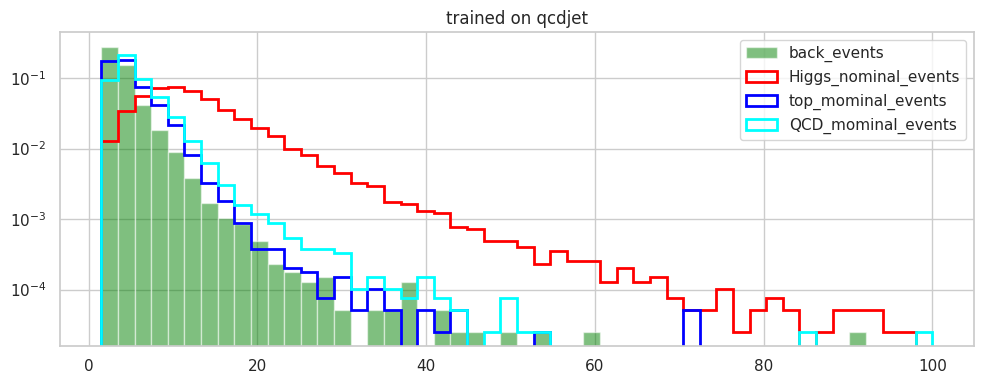

In [55]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming losses_dfs dictionary is already created from the previous steps

# Extract the relevant DataFrames from losses_dfs dictionary
back_loss = losses_dfs['RUN2_test2']
sig_loss1 = losses_dfs['Higgs_nominal_test']
sig_loss2 = losses_dfs['Top_nominal_test_ttbar']
sig_loss3 = losses_dfs['QCD_nominal_test']



min_value_mae_loss = min(
    np.min(back_loss['mae_loss']),
    np.min(sig_loss1['mae_loss']),
    np.min(sig_loss2['mae_loss']),np.min(sig_loss3['mae_loss'])
)
max_value_mae_loss = max(np.max(back_loss['mae_loss']),np.max(sig_loss1['mae_loss']),np.max(sig_loss2['mae_loss']),np.max(sig_loss3['mae_loss']))
max_value_mae_loss=100
plt.figure(figsize=(10, 4))
plt.hist(back_loss['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, alpha=0.5, color='green', label='back_events', density=True)
plt.hist(sig_loss1['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='red', histtype='step', linewidth=2, label='Higgs_nominal_events', density=True)
plt.hist(sig_loss2['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='blue', histtype='step', linewidth=2, label='top_mominal_events', density=True)
plt.hist(sig_loss3['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='cyan', histtype='step', linewidth=2, label='QCD_mominal_events', density=True)
plt.title("trained on qcdjet")
plt.legend()

plt.legend()


plt.tight_layout()
plt.savefig("VAE_test_loss.png")
plt.show()


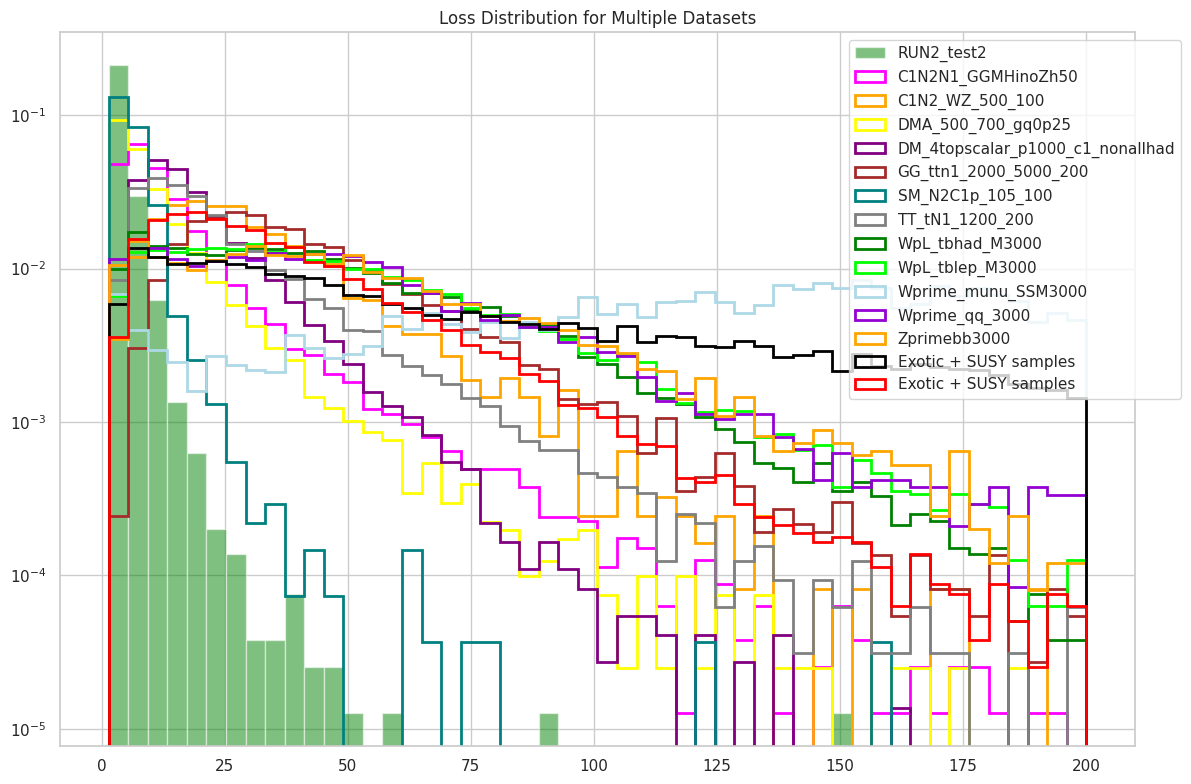

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming losses_dfs dictionary is already created
back_loss = losses_dfs['RUN2_test2']
sig_loss1 = losses_dfs['Higgs_nominal_test']
sig_loss2 = losses_dfs['Top_nominal_test_ttbar']
sig_loss3 = losses_dfs['QCD_nominal_test']
sig_loss4 = losses_dfs['C1N2N1_GGMHinoZh50']
sig_loss5 = losses_dfs['C1N2_WZ _500_100']
sig_loss6 = losses_dfs['DMA_500_700_gq0p25']
sig_loss7 = losses_dfs['DM_4topscalar_p1000_c1_nonallhad']
sig_loss8 = losses_dfs['GG_ttn1_2000_5000_200']
sig_loss9 = losses_dfs['SM4tops']
sig_loss10 = losses_dfs['SM_N2C1p_105_100']
sig_loss11 = losses_dfs['TT_tN1_1200_200']
sig_loss12 = losses_dfs['VBFH125_bb']
sig_loss13 = losses_dfs['WpL_tbhad_M3000']
sig_loss14 = losses_dfs['WpL_tblep_M3000']
sig_loss15 = losses_dfs['Wprime_munu_SSM3000']
sig_loss16 = losses_dfs['Wprime_qq_3000']
sig_loss17 = losses_dfs['Zprimebb3000']
sig_loss18 = losses_dfs['ttH125_ZZ4l_allhad']
sig_loss19 = losses_dfs['ttH125_ZZ4l_semilep']
#exotic_loss =   sig_loss6['mae_loss'] + sig_loss7['mae_loss']  + sig_loss13['mae_loss'] + sig_loss14['mae_loss'] + sig_loss15['mae_loss'] + sig_loss16['mae_loss'] + sig_loss17['mae_loss']
#susy_loss = sig_loss4['mae_loss'] + sig_loss5['mae_loss'] + sig_loss8['mae_loss'] + sig_loss10['mae_loss'] + sig_loss11['mae_loss'] 
exotic_loss =  losses_dfs['Exotic_test']# sig_loss6 + sig_loss7  + sig_loss13 + sig_loss14 + sig_loss15 + sig_loss16 + sig_loss17
susy_loss = losses_dfs['SUSY_test']#sig_loss4 + sig_loss5 + sig_loss8 + sig_loss10 + sig_loss11 


# Find the min and max values for 'mae_loss' across all datasets
min_value_mae_loss = min([np.min(df['mae_loss']) for df in losses_dfs.values()])
max_value_mae_loss = max([np.max(df['mae_loss']) for df in losses_dfs.values()])
max_value_mae_loss = 200  # Set a fixed max value for the histogram range

# Create a new figure for plotting
plt.figure(figsize=(12, 8))

# Plot histograms for all datasets manually
plt.hist(back_loss['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, alpha=0.5, color='green', label='RUN2_test2', density=True)
#plt.hist(sig_loss1['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='red', histtype='step', linewidth=2, label='Higgs_nominal_test', density=True)
#plt.hist(sig_loss2['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='blue', histtype='step', linewidth=2, label='Top_nominal_test_ttbar', density=True)
#plt.hist(sig_loss3['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='cyan', histtype='step', linewidth=2, label='QCD_nominal_test', density=True)
plt.hist(sig_loss4['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='magenta', histtype='step', linewidth=2, label='C1N2N1_GGMHinoZh50', density=True)
plt.hist(sig_loss5['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='orange', histtype='step', linewidth=2, label='C1N2_WZ_500_100', density=True)
plt.hist(sig_loss6['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='yellow', histtype='step', linewidth=2, label='DMA_500_700_gq0p25', density=True)
plt.hist(sig_loss7['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='purple', histtype='step', linewidth=2, label='DM_4topscalar_p1000_c1_nonallhad', density=True)
plt.hist(sig_loss8['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='brown', histtype='step', linewidth=2, label='GG_ttn1_2000_5000_200', density=True)
#plt.hist(sig_loss9['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='pink', histtype='step', linewidth=2, label='SM4tops', density=True)
plt.hist(sig_loss10['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='teal', histtype='step', linewidth=2, label='SM_N2C1p_105_100', density=True)
plt.hist(sig_loss11['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='gray', histtype='step', linewidth=2, label='TT_tN1_1200_200', density=True)
#plt.hist(sig_loss12['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='blueviolet', histtype='step', linewidth=2, label='VBFH125_bb', density=True)
plt.hist(sig_loss13['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='green', histtype='step', linewidth=2, label='WpL_tbhad_M3000', density=True)
plt.hist(sig_loss14['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='lime', histtype='step', linewidth=2, label='WpL_tblep_M3000', density=True)
plt.hist(sig_loss15['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='lightblue', histtype='step', linewidth=2, label='Wprime_munu_SSM3000', density=True)
plt.hist(sig_loss16['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='darkviolet', histtype='step', linewidth=2, label='Wprime_qq_3000', density=True)
plt.hist(sig_loss17['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='orange', histtype='step', linewidth=2, label='Zprimebb3000', density=True)
#plt.hist(sig_loss18['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='indigo', histtype='step', linewidth=2, label='ttH125_ZZ4l_allhad', density=True)
#plt.hist(sig_loss19['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='red', histtype='step', linewidth=2, label='ttH125_ZZ4l_semilep', density=True)

# Plot the summed exotic and SUSY histograms
plt.hist(exotic_loss['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='black', histtype='step', linewidth=2, label='Exotic + SUSY samples', density=True)
plt.hist(susy_loss['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='red', histtype='step', linewidth=2, label='Exotic + SUSY samples', density=True)

# Add title and legend
plt.title("Loss Distribution for Multiple Datasets")
plt.legend(loc='upper right', bbox_to_anchor=(1.05, 1))

# Adjust layout and save the plot
plt.tight_layout()
plt.savefig("combined_loss_plot.png")
plt.show()


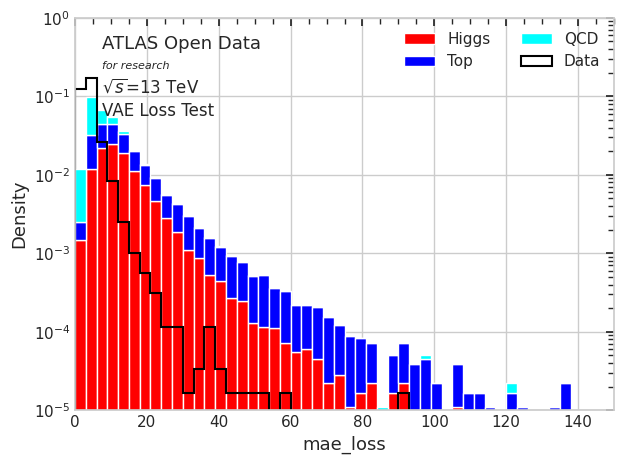

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator, MaxNLocator

# Prepare the data
data = {
    'data': {
        'mae_loss': losses_dfs['RUN2_test2']['mae_loss'],
        'totalWeight': np.ones_like(losses_dfs['RUN2_test2']['mae_loss']),
    },
    'Higgs': {
        'mae_loss': losses_dfs['Higgs_nominal_test']['mae_loss'],
        'totalWeight': np.ones_like(losses_dfs['Higgs_nominal_test']['mae_loss']),
    },
    'Top': {
        'mae_loss': losses_dfs['Top_nominal_test']['mae_loss'],
        'totalWeight': np.ones_like(losses_dfs['Top_nominal_test']['mae_loss']),
    },
    'QCD': {
        'mae_loss': losses_dfs['QCD_nominal_test']['mae_loss'],
        'totalWeight': np.ones_like(losses_dfs['QCD_nominal_test']['mae_loss']),
    }
}

samples_to_plot = {
    'Higgs': {'color': 'red'},
    'Top': {'color': 'blue'},
    'QCD': {'color': 'cyan'},
}

def plot_loss_data(data, samples_to_plot, x_variable='mae_loss', region_label='VAE Loss Test'):
    
    bin_edges = np.linspace(0, 150, 51)  # 50 bins from 0 to 300
    bin_centres = (bin_edges[:-1] + bin_edges[1:]) / 2

    mc_x = []
    mc_colors = []
    mc_labels = []
    
    main_axes = plt.gca()

    for s in samples_to_plot:
        mc_x.append(data[s][x_variable])
        mc_colors.append(samples_to_plot[s]['color'])
        mc_labels.append(s)

    # plot stacked bars for MC with density=True, no weights
    main_axes.hist(mc_x, bins=bin_edges,
                   stacked=True,
                   color=mc_colors, label=mc_labels, density=True)

    # plot data as histogram with density=True, no weights
    main_axes.hist(data['data'][x_variable],
                   bins=bin_edges,
                   histtype='step',
                   color='black',
                   linewidth=1.5,
                   label='Data', density=True)

    # axis settings
    main_axes.set_xlim(bin_edges[0], bin_edges[-1])
    main_axes.set_xlabel(x_variable, fontsize=13)
    main_axes.set_ylabel('Density', fontsize=13)
    main_axes.xaxis.set_minor_locator(AutoMinorLocator())
    main_axes.yaxis.set_minor_locator(AutoMinorLocator())
    main_axes.tick_params(which='both', direction='in', top=True, right=True)
    main_axes.yaxis.set_major_locator(MaxNLocator(integer=True))

    # set y-axis to logarithmic scale
    main_axes.set_yscale('log')

    # set y-limits from 10^-5 to 10^0
    main_axes.set_ylim(1e-5, 1e-0)

    # text
    plt.text(0.05, 0.92, 'ATLAS Open Data', transform=main_axes.transAxes, fontsize=13)
    plt.text(0.05, 0.87, 'for research', transform=main_axes.transAxes, fontsize=8, style='italic')
    plt.text(0.05, 0.81, r'$\sqrt{s}$=13 TeV', transform=main_axes.transAxes, fontsize=12)
    plt.text(0.05, 0.75, region_label, transform=main_axes.transAxes, fontsize=12)

    # legend
    main_axes.legend(ncol=2, frameon=False)

    plt.tight_layout()
    plt.savefig('VAE_loss_final_histogram_density_no_weights_log_y_custom_limits.png')
    plt.show()


# Finally call the function
plot_loss_data(data, samples_to_plot)


In [58]:
# Ensure both DataFrames have the same index
x_test_aligned = dataset['RUN2_test2'][:20000].reset_index(drop=True)
losses_aligned = losses_dfs['RUN2_test2']['mae_loss'].reset_index(drop=True)

# Apply filtering condition
train = x_test_aligned[losses_aligned > 60]

In [59]:
import numpy as np
import pandas as pd

# Function to calculate transverse invariant mass
def transverse_invariant_mass(pt1, pt2, phi1, phi2):
    delta_phi = np.abs(phi1 - phi2)
    delta_phi = np.minimum(delta_phi, 2 * np.pi - delta_phi)  # Ensure delta_phi is in the range [0, pi]
    
    m_T_squared = 2 * pt1 * pt2 * (1 - np.cos(delta_phi))
    return np.sqrt(m_T_squared) if m_T_squared > 0 else 0

# Function to calculate Di-photon invariant mass (M_gg)
def di_photon_mass(pt1, eta1, phi1, pt2, eta2, phi2):
    delta_eta = eta1 - eta2
    delta_phi = np.abs(phi1 - phi2)
    delta_phi = np.minimum(delta_phi, 2 * np.pi - delta_phi)  # Ensure delta_phi is in the range [0, pi]
    
    m_gg_squared = 2 * pt1 * pt2 * (np.cosh(delta_eta) - np.cos(delta_phi))
    return np.sqrt(m_gg_squared) if m_gg_squared > 0 else 0

# Function to calculate Four-photon invariant mass (M_gggg)
def four_photon_mass(pt1, eta1, phi1, pt2, eta2, phi2, pt3, eta3, phi3, pt4, eta4, phi4):
    m_gg1 = di_photon_mass(pt1, eta1, phi1, pt2, eta2, phi2)
    m_gg2 = di_photon_mass(pt3, eta3, phi3, pt4, eta4, phi4)
    m_gggg_squared = m_gg1**2 + m_gg2**2 + 2 * m_gg1 * m_gg2 * (np.cosh(eta1 - eta3) - np.cos(phi1 - phi3))
    return np.sqrt(m_gggg_squared) if m_gggg_squared > 0 else 0

# Function to calculate Tri-photon invariant mass (M_ggg)
def tri_photon_mass(pt1, eta1, phi1, pt2, eta2, phi2, pt3, eta3, phi3):
    m_gg = di_photon_mass(pt1, eta1, phi1, pt2, eta2, phi2)
    m_ggg_squared = m_gg**2 + pt3**2 + 2 * m_gg * pt3 * (np.cosh(eta1 - eta3) - np.cos(phi1 - phi3))
    return np.sqrt(m_ggg_squared) if m_ggg_squared > 0 else 0

# Function to calculate Di-lepton invariant mass (M_ll)
def di_lepton_mass(pt1, eta1, phi1, pt2, eta2, phi2):
    delta_eta = eta1 - eta2
    delta_phi = np.abs(phi1 - phi2)
    delta_phi = np.minimum(delta_phi, 2 * np.pi - delta_phi)
    
    m_ll_squared = 2 * pt1 * pt2 * (np.cosh(delta_eta) - np.cos(delta_phi))
    return np.sqrt(m_ll_squared) if m_ll_squared > 0 else 0
def tri_lepton_mass(pt1, eta1, phi1, pt2, eta2, phi2, pt3, eta3, phi3):
    # Calculate energy of each lepton using E = sqrt(pT^2 + m^2), assuming m = 0 for massless leptons (electrons/photons)
    E1 = np.sqrt(pt1**2 + (pt1 * np.sinh(eta1))**2)  # Energy of lepton 1
    E2 = np.sqrt(pt2**2 + (pt2 * np.sinh(eta2))**2)  # Energy of lepton 2
    E3 = np.sqrt(pt3**2 + (pt3 * np.sinh(eta3))**2)  # Energy of lepton 3

    # Calculate momentum components for each lepton
    px1 = pt1 * np.cos(phi1)
    py1 = pt1 * np.sin(phi1)
    pz1 = pt1 * np.sinh(eta1)

    px2 = pt2 * np.cos(phi2)
    py2 = pt2 * np.sin(phi2)
    pz2 = pt2 * np.sinh(eta2)

    px3 = pt3 * np.cos(phi3)
    py3 = pt3 * np.sin(phi3)
    pz3 = pt3 * np.sinh(eta3)

    # Calculate the total energy and momentum of the system
    E_total = E1 + E2 + E3
    px_total = px1 + px2 + px3
    py_total = py1 + py2 + py3
    pz_total = pz1 + pz2 + pz3

    # Calculate the invariant mass of the three-lepton system
    mass_3l_squared = E_total**2 - (px_total**2 + py_total**2 + pz_total**2)
    return np.sqrt(mass_3l_squared) if mass_3l_squared > 0 else 0

def four_lepton_mass(pt1, eta1, phi1, pt2, eta2, phi2, pt3, eta3, phi3, pt4, eta4, phi4):
    # Calculate the energy and momentum components for each lepton
    def get_energy_and_momentum(pt, eta, phi):
        energy = np.sqrt(pt**2 + (0.000511)**2)  # Assuming electron mass (in GeV)
        px = pt * np.cos(phi)
        py = pt * np.sin(phi)
        pz = pt * np.sinh(eta)
        return energy, np.array([px, py, pz])

    # Energy and momentum of each lepton
    E1, p1 = get_energy_and_momentum(pt1, eta1, phi1)
    E2, p2 = get_energy_and_momentum(pt2, eta2, phi2)
    E3, p3 = get_energy_and_momentum(pt3, eta3, phi3)
    E4, p4 = get_energy_and_momentum(pt4, eta4, phi4)

    # Total energy and total momentum
    total_energy = E1 + E2 + E3 + E4
    total_momentum = p1 + p2 + p3 + p4

    # Invariant mass of the four-lepton system
    M_4l_squared = total_energy**2 - np.dot(total_momentum, total_momentum)
    M_4l = np.sqrt(M_4l_squared) if M_4l_squared > 0 else 0
    return M_4l
# Function to calculate transverse mass with MET (M_T)
def transverse_mass_with_met(pt, phi, met_pt, met_phi):
    delta_phi = np.abs(phi - met_phi)
    delta_phi = np.minimum(delta_phi, 2 * np.pi - delta_phi)
    
    m_T_squared = 2 * pt * met_pt * (1 - np.cos(delta_phi))
    return np.sqrt(m_T_squared) if m_T_squared > 0 else 0

# Function to classify events based on various mass combinations and properties
def classify_event(row, M_gg, M_ggg, M_ll, M_lll, M_llll, M_T, M_Tgg, MET1_mpx, MET1_mpy, M_gggg):
    classification = "Unknown"
    decay_channel = ""

    # Calculate MET magnitude
    MET_magnitude = np.sqrt(MET1_mpx**2 + MET1_mpy**2)

    # 1. Higgs decay via diphoton (H -> γγ)
    if 120 < M_gg < 130:
        classification = "Higgs decay"
        decay_channel = "Diphoton"

    # 2. Higgs decay via four leptons (H -> ZZ -> 4l)
    elif 120 < M_llll < 130:
        classification = "Higgs decay"
        decay_channel = "Four-lepton"

    # 3. Tri-photon BSM candidate (Possible Higgs or new physics)
    elif 100 < M_ggg < 140:
        classification = "BSM Candidate (Possible Higgs or new physics)"
        decay_channel = "Tri-photon"

    # 4. Four-photon system candidate (BSM or new physics)
    elif 200 < M_gggg < 300:
        classification = "BSM Candidate (4-photon system)"
        decay_channel = "Four-photon"

    # 5. Z boson decay (Z -> ll)
    elif 80 < M_ll < 100:
        classification = "Z boson decay"
        decay_channel = "Dilepton"
    
    # 6. Z boson decay (Z -> 4l)
    elif 80 < M_llll < 100:
        classification = "Z boson decay"
        decay_channel = "Four-lepton"

    # 7. W boson decay (W -> l + MET)
    elif M_T > 50:
        classification = "W boson decay"
        decay_channel = "Lepton + MET"

    # 8. Multi-photon BSM candidate
    elif row['Njets'] > 6 and row['Nphotons'] == 3:
        classification = "BSM Candidate"
        decay_channel = "Tri-photon"

    # 9. New physics via MET components and transverse mass
    elif M_Tgg > 100 and MET_magnitude > 100:
        classification = "BSM Candidate (MET + Photons)"
        decay_channel = "Invisible decay or new resonance"

    # 10. H -> γγ + jets (Signal + jets)
    elif 120 < M_gg < 130 and row['Njets'] > 4:
        classification = "Signal + Jets"
        decay_channel = "H -> γγ + jets"

    # 11. H -> Z -> ll + MET (Associated production)
    elif 120 < M_llll < 130 and M_T > 50:
        classification = "Higgs decay"
        decay_channel = "Z -> ll + MET"

    # 12. BSM candidate with high MET and lepton
    elif M_T > 80 and MET_magnitude > 100:
        classification = "BSM Candidate"
        decay_channel = "MET + Lepton"

    # 13. H -> γγ with very high transverse mass
    elif 120 < M_gg < 130 and M_T > 200:
        classification = "Higgs decay"
        decay_channel = "H -> γγ with high transverse mass"

    # 14. High mass BSM resonance decay
    elif 500 < M_gggg < 700:
        classification = "High mass BSM resonance decay"
        decay_channel = "Four-photon high mass"

    return classification, decay_channel


# Main function to process the dataframe
def process_dataframe(df):
    results = []
    
    # Iterate over each row in the dataframe
    for index, row in df.iterrows():
        # Extract photon and lepton data
        photon1_pt = row['photon1_pt']
        photon1_eta = row['photon1_eta']
        photon1_phi = row['photon1_phi']
        
        photon2_pt = row['photon2_pt']
        photon2_eta = row['photon2_eta']
        photon2_phi = row['photon2_phi']
        
        # Handle cases with more than two photons
        if 'photon3_pt' in row:
            photon3_pt = row['photon3_pt']
            photon3_eta = row['photon3_eta']
            photon3_phi = row['photon3_phi']
        
        if 'photon4_pt' in row:
            photon4_pt = row['photon4_pt']
            photon4_eta = row['photon4_eta']
            photon4_phi = row['photon4_phi']
        
        # Leptons data
        lepton1_pt = row['lepton1_pt']
        lepton1_eta = row['lepton1_eta']
        lepton1_phi = row['lepton1_phi']
        
        lepton2_pt = row['lepton2_pt']
        lepton2_eta = row['lepton2_eta']
        lepton2_phi = row['lepton2_phi']
        
        lepton3_pt = row['lepton3_pt']
        lepton3_eta = row['lepton3_eta']
        lepton3_phi = row['lepton3_phi']
        
        lepton4_pt = row['lepton4_pt']
        lepton4_eta = row['lepton4_eta']
        lepton4_phi = row['lepton4_phi']
        

        MET1_mpx = row['MET1_px']
        MET1_mpy = row['MET1_py']
        
        # Calculate mass variables
        M_gg = di_photon_mass(photon1_pt, photon1_eta, photon1_phi, photon2_pt, photon2_eta, photon2_phi)
        M_ggg = tri_photon_mass(photon1_pt, photon1_eta, photon1_phi, photon2_pt, photon2_eta, photon2_phi, photon3_pt, photon3_eta, photon3_phi) if 'photon3_pt' in row else 0
        M_gggg = four_photon_mass(photon1_pt, photon1_eta, photon1_phi, photon2_pt, photon2_eta, photon2_phi, photon3_pt, photon3_eta, photon3_phi, photon4_pt, photon4_eta, photon4_phi) if 'photon4_pt' in row else 0
        
        M_ll = di_lepton_mass(lepton1_pt, lepton1_eta, lepton1_phi, lepton2_pt, lepton2_eta, lepton2_phi)
        M_lll = tri_lepton_mass(lepton1_pt, lepton1_eta, lepton1_phi, lepton2_pt, lepton2_eta, lepton2_phi, lepton3_pt, lepton3_eta, lepton3_phi)
        M_llll = four_lepton_mass(lepton1_pt, lepton1_eta, lepton1_phi, lepton2_pt, lepton2_eta, lepton2_phi,lepton3_pt, lepton3_eta, lepton3_phi, lepton4_pt, lepton4_eta, lepton4_phi)  # Adjust based on your lepton data
        
        M_T = transverse_invariant_mass(lepton1_pt, lepton2_pt, lepton1_phi, lepton2_phi)
        M_Tgg = transverse_invariant_mass(photon1_pt, photon2_pt, photon1_phi, photon2_phi)
        
        
        # Classify event
        classification, decay_channel = classify_event(row, M_gg, M_ggg, M_ll, M_lll, M_llll, M_T, M_Tgg, MET1_mpx, MET1_mpy, M_gggg)
        
        results.append({
            'classification': classification,
            'decay_channel': decay_channel,
            'M_gg': M_gg,
            'M_ggg': M_ggg,
            'M_gggg': M_gggg,
            'M_ll': M_ll,
            'M_llll': M_llll,
            'M_T': M_T,
            'M_Tgg': M_Tgg,
            'MET1_mpx': MET1_mpx,
            'MET1_mpy': MET1_mpy
        })
    
    return pd.DataFrame(results)
result_df = process_dataframe(train)
result_df

,classification,decay_channel,M_gg,M_ggg,M_gggg,M_ll,M_llll,M_T,M_Tgg,MET1_mpx,MET1_mpy
0,BSM Candidate (MET + Photons),Invisible decay or new resonance,2851.799514,0.0,2851.799514,0,0,0,2352.12714,-9578.889648,-4611.792969
1,Unknown,,0.000000,99.0,0.000000,0,0,0,0.00000,-13274.097656,8149.813477


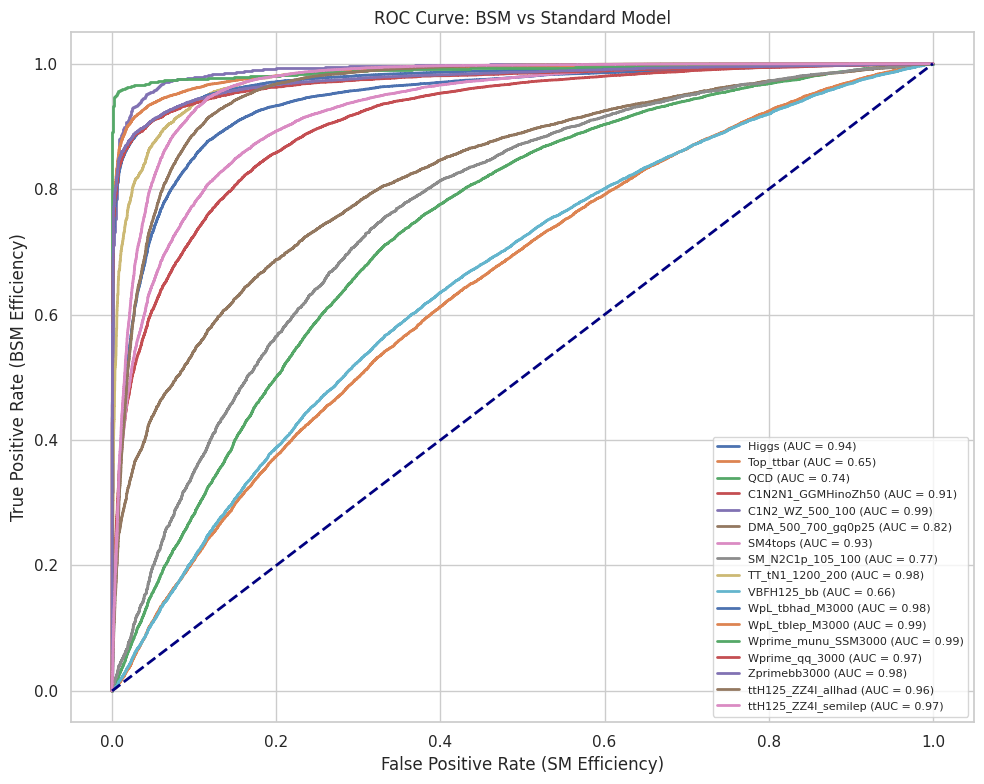

In [60]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Background loss and labels
background_loss = losses_dfs['RUN2_test2']
background_labels = np.zeros(len(background_loss))

# Dictionary of signal losses
signals = {
    'Higgs': losses_dfs['Higgs_nominal_test'],
    'Top_ttbar': losses_dfs['Top_nominal_test_ttbar'],
    'QCD': losses_dfs['QCD_nominal_test'],
    'C1N2N1_GGMHinoZh50': losses_dfs['C1N2N1_GGMHinoZh50'],
    'C1N2_WZ_500_100': losses_dfs['C1N2_WZ _500_100'],
    'DMA_500_700_gq0p25': losses_dfs['DMA_500_700_gq0p25'],
    'SM4tops': losses_dfs['SM4tops'],
    'SM_N2C1p_105_100': losses_dfs['SM_N2C1p_105_100'],
    'TT_tN1_1200_200': losses_dfs['TT_tN1_1200_200'],
    'VBFH125_bb': losses_dfs['VBFH125_bb'],
    'WpL_tbhad_M3000': losses_dfs['WpL_tbhad_M3000'],
    'WpL_tblep_M3000': losses_dfs['WpL_tblep_M3000'],
    'Wprime_munu_SSM3000': losses_dfs['Wprime_munu_SSM3000'],
    'Wprime_qq_3000': losses_dfs['Wprime_qq_3000'],
    'Zprimebb3000': losses_dfs['Zprimebb3000'],
    'ttH125_ZZ4l_allhad': losses_dfs['ttH125_ZZ4l_allhad'],
    'ttH125_ZZ4l_semilep': losses_dfs['ttH125_ZZ4l_semilep'],
}

plt.figure(figsize=(10, 8))

# Loop through each signal and compute its ROC curve
for signal_name, signal_loss in signals.items():
    min_len = min(len(background_loss), len(signal_loss))
    back = background_loss[:min_len]
    sig = signal_loss[:min_len]

    all_losses = np.concatenate([back, sig])
    all_labels = np.concatenate([np.zeros(min_len), np.ones(min_len)])

    fpr, tpr, _ = roc_curve(all_labels, all_losses)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, lw=2, label=f'{signal_name} (AUC = {roc_auc:.2f})')

# Diagonal reference line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

# Labels and styling
plt.xlabel("False Positive Rate (SM Efficiency)")
plt.ylabel("True Positive Rate (BSM Efficiency)")
plt.title("ROC Curve: BSM vs Standard Model")
plt.legend(loc="lower right", fontsize=8)
plt.grid(True)

# Show and save plot
plt.tight_layout()
plt.savefig("rocs.png")
plt.show()


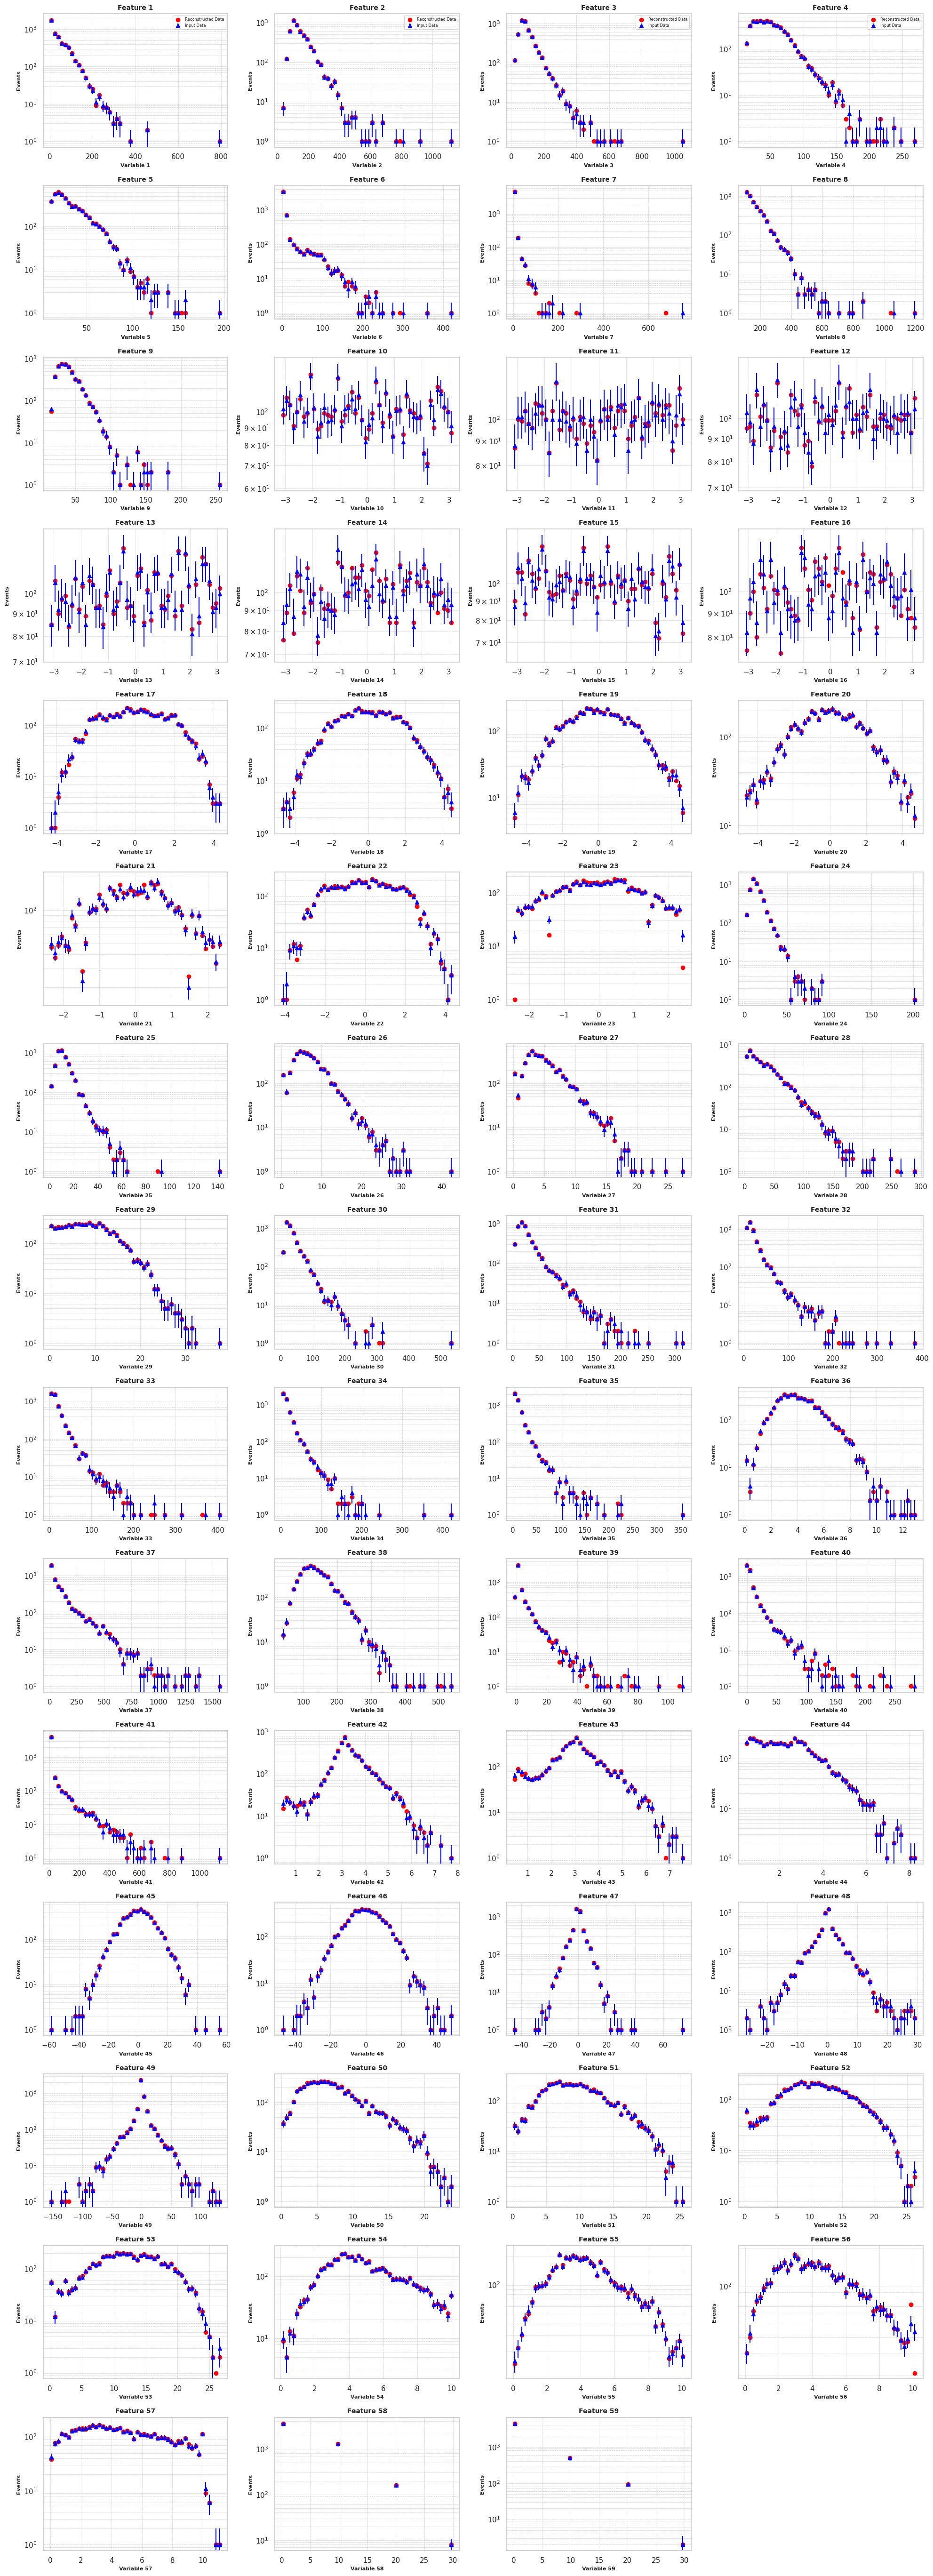

In [61]:

import matplotlib.pyplot as plt
import numpy as np

# Define your data arrays (replace these with your actual data)
jet3_recn = reconstructed_x['RUN2_test2'][:5000]
jet3_X = x_test['RUN2_test2'][:5000]

# Combine datasets into a list
datasets = [
    jet3_recn,
    jet3_X
]

# Initialize min and max values
min_values = []
max_values = []
min_cols = min(data.shape[1] for data in datasets)

# Loop through each feature index and calculate min and max values
for i in range(min_cols):
    min_val = min(np.min(data[:, i]) for data in datasets)
    max_val = max(np.max(data[:, i]) for data in datasets)
    min_values.append(min_val)
    max_values.append(max_val)

# Function to plot histograms with dots and error bars
def plot_histogram_with_dots_and_errors(real_data, decoded_data, min_value, max_value, xlabel, title, subplot_index, bins=50):
    range_values = (min_value, max_value)

    real_hist, bin_edges = np.histogram(real_data, bins=bins, range=range_values, density=False)
    decoded_hist, _ = np.histogram(decoded_data, bins=bins, range=range_values, density=False)

    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])

    # Calculate error as sqrt(counts) for real data
    real_errors = np.sqrt(real_hist)

    plt.subplot(22, 4, subplot_index)  # Adjust to 21 rows x 4 columns layout
    plt.scatter(bin_centers, decoded_hist, color='red', label='Reconstructed Data', marker='o')
    plt.errorbar(bin_centers, real_hist, yerr=real_errors, fmt='^', color='blue', label='Input Data', linestyle='None')

    plt.xscale('linear')
    plt.yscale('log')  # Logarithmic scale for y-axis

    plt.xlabel(xlabel, fontsize=8, fontweight='bold')
    plt.ylabel('Events', fontsize=8, fontweight='bold')
    plt.title(title, fontsize=10, fontweight='bold')

    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    if subplot_index <= 4:  # Show legend only on the first row
        plt.legend(fontsize=6)

# Create subplots
plt.figure(figsize=(20, 80))  # Adjust size to fit all subplots

# Plot for each variable
total_vars = min_cols
for i in range(total_vars):
    real_data = jet3_X[:, i]
    decoded_data = jet3_recn[:, i]
    xlabel = f'Variable {i + 1}'  # Generic labels for variables
    title = f'Feature {i + 1}'
    plot_histogram_with_dots_and_errors(real_data, decoded_data, min_values[i], max_values[i], xlabel, title, i + 1)

plt.tight_layout()

# Save the figure
plt.savefig("histograms_84_variables.png")  # Save the figure

# Display the plot
plt.show()


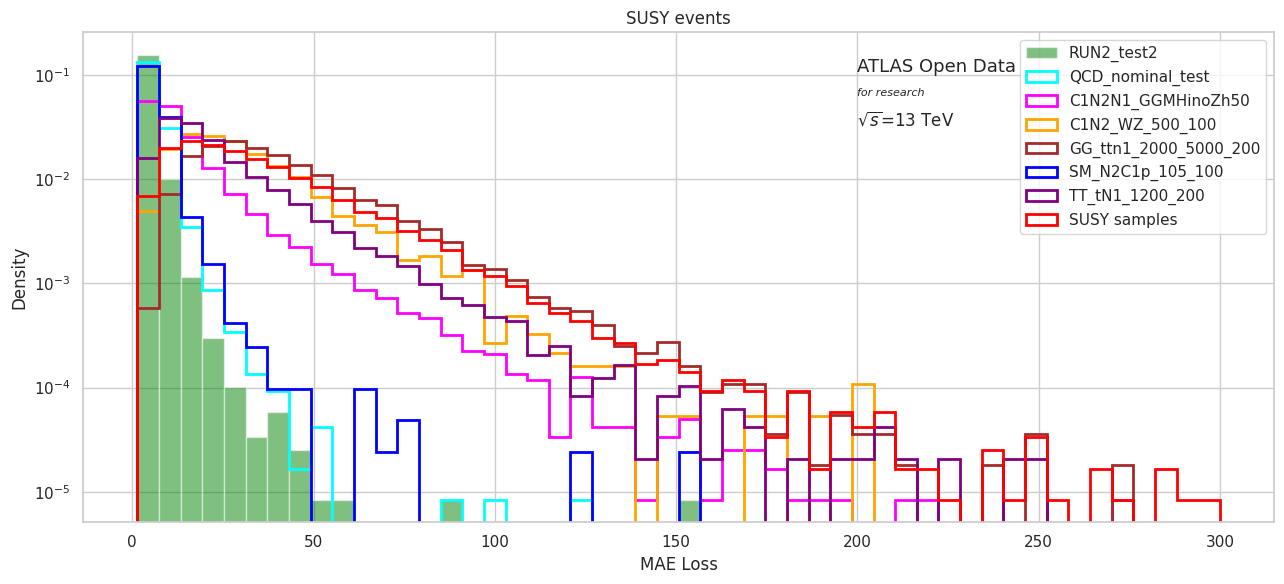

In [62]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming losses_dfs dictionary is already created
back_loss = losses_dfs['RUN2_test2']
sig_loss1 = losses_dfs['Higgs_nominal_test']
sig_loss2 = losses_dfs['Top_nominal_test_ttbar']
sig_loss3 = losses_dfs['QCD_nominal_test']
sig_loss4 = losses_dfs['C1N2N1_GGMHinoZh50']
sig_loss5 = losses_dfs['C1N2_WZ _500_100']
sig_loss6 = losses_dfs['DMA_500_700_gq0p25']
sig_loss7 = losses_dfs['DM_4topscalar_p1000_c1_nonallhad']
sig_loss8 = losses_dfs['GG_ttn1_2000_5000_200']
sig_loss9 = losses_dfs['SM4tops']
sig_loss10 = losses_dfs['SM_N2C1p_105_100']
sig_loss11 = losses_dfs['TT_tN1_1200_200']
sig_loss12 = losses_dfs['VBFH125_bb']
sig_loss13 = losses_dfs['WpL_tbhad_M3000']
sig_loss14 = losses_dfs['WpL_tblep_M3000']
sig_loss15 = losses_dfs['Wprime_munu_SSM3000']
sig_loss16 = losses_dfs['Wprime_qq_3000']
sig_loss17 = losses_dfs['Zprimebb3000']
sig_loss18 = losses_dfs['ttH125_ZZ4l_allhad']
sig_loss19 = losses_dfs['ttH125_ZZ4l_semilep']
#exotic_loss =   sig_loss6['mae_loss'] + sig_loss7['mae_loss']  + sig_loss13['mae_loss'] + sig_loss14['mae_loss'] + sig_loss15['mae_loss'] + sig_loss16['mae_loss'] + sig_loss17['mae_loss']
#susy_loss = sig_loss4['mae_loss'] + sig_loss5['mae_loss'] + sig_loss8['mae_loss'] + sig_loss10['mae_loss'] + sig_loss11['mae_loss'] 
exotic_loss =  losses_dfs['Exotic_test']# sig_loss6 + sig_loss7  + sig_loss13 + sig_loss14 + sig_loss15 + sig_loss16 + sig_loss17
susy_loss = losses_dfs['SUSY_test']#sig_loss4 + sig_loss5 + sig_loss8 + sig_loss10 + sig_loss11 


# Find the min and max values for 'mae_loss' across all datasets
min_value_mae_loss = min([np.min(df['mae_loss']) for df in losses_dfs.values()])
max_value_mae_loss = max([np.max(df['mae_loss']) for df in losses_dfs.values()])
max_value_mae_loss = 300  # Set a fixed max value for the histogram range

# Create a new figure for plotting
plt.figure(figsize=(13, 6))

# Plot histograms for all datasets manually
plt.hist(back_loss['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, alpha=0.5, color='green', label='RUN2_test2', density=True)
#plt.hist(sig_loss1['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='blue', histtype='step', linewidth=2, label='Higgs_nominal_test', density=True)
#plt.hist(sig_loss2['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='cyan', histtype='step', linewidth=2, label='ttbar', density=True)
plt.hist(sig_loss3['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='cyan', histtype='step', linewidth=2, label='QCD_nominal_test', density=True)
plt.hist(sig_loss4['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='magenta', histtype='step', linewidth=2, label='C1N2N1_GGMHinoZh50', density=True)
plt.hist(sig_loss5['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='orange', histtype='step', linewidth=2, label='C1N2_WZ_500_100', density=True)
#plt.hist(sig_loss6['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='yellow', histtype='step', linewidth=2, label='DMA_500_700_gq0p25', density=True)
#plt.hist(sig_loss7['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='purple', histtype='step', linewidth=2, label='DM_4topscalar_p1000_c1_nonallhad', density=True)
plt.hist(sig_loss8['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='brown', histtype='step', linewidth=2, label='GG_ttn1_2000_5000_200', density=True)
#plt.hist(sig_loss9['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='orange', histtype='step', linewidth=2, label='SM4tops', density=True)
plt.hist(sig_loss10['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='blue', histtype='step', linewidth=2, label='SM_N2C1p_105_100', density=True)
plt.hist(sig_loss11['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='purple', histtype='step', linewidth=2, label='TT_tN1_1200_200', density=True)
#plt.hist(sig_loss12['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='blueviolet', histtype='step', linewidth=2, label='VBFH125_bb', density=True)
#plt.hist(sig_loss13['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='green', histtype='step', linewidth=2, label='WpL_tbhad_M3000', density=True)
#plt.hist(sig_loss14['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='lime', histtype='step', linewidth=2, label='WpL_tblep_M3000', density=True)
#plt.hist(sig_loss15['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='lightblue', histtype='step', linewidth=2, label='Wprime_munu_SSM3000', density=True)
#plt.hist(sig_loss16['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='darkviolet', histtype='step', linewidth=2, label='Wprime_qq_3000', density=True)
#plt.hist(sig_loss17['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='orange', histtype='step', linewidth=2, label='Zprimebb3000', density=True)
#plt.hist(sig_loss18['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='indigo', histtype='step', linewidth=2, label='ttH125_ZZ4l_allhad', density=True)
#plt.hist(sig_loss19['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='red', histtype='step', linewidth=2, label='ttH125_ZZ4l_semilep', density=True)

# Plot the summed exotic and SUSY histograms
#plt.hist(exotic_loss['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='black', histtype='step', linewidth=2, label='Exotic samples', density=True)
plt.hist(susy_loss['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='red', histtype='step', linewidth=2, label='SUSY samples', density=True)
# Labels
plt.xlabel('MAE Loss')
plt.ylabel('Density')
plt.title('Loss Distribution for Multiple Datasets')

# Annotations
plt.text(.65, 0.92, 'ATLAS Open Data', transform=plt.gca().transAxes, fontsize=13)
plt.text(0.65, 0.87, 'for research', transform=plt.gca().transAxes, fontsize=8, style='italic')
plt.text(0.65, 0.81, r'$\sqrt{s}$=13 TeV', transform=plt.gca().transAxes, fontsize=12)# Add title and legend
plt.title("SUSY events")
plt.legend(loc='upper right', bbox_to_anchor=(1., 1))

# Adjust layout and save the plot
plt.tight_layout()
plt.savefig("combined_loss_plot.png")
plt.show()


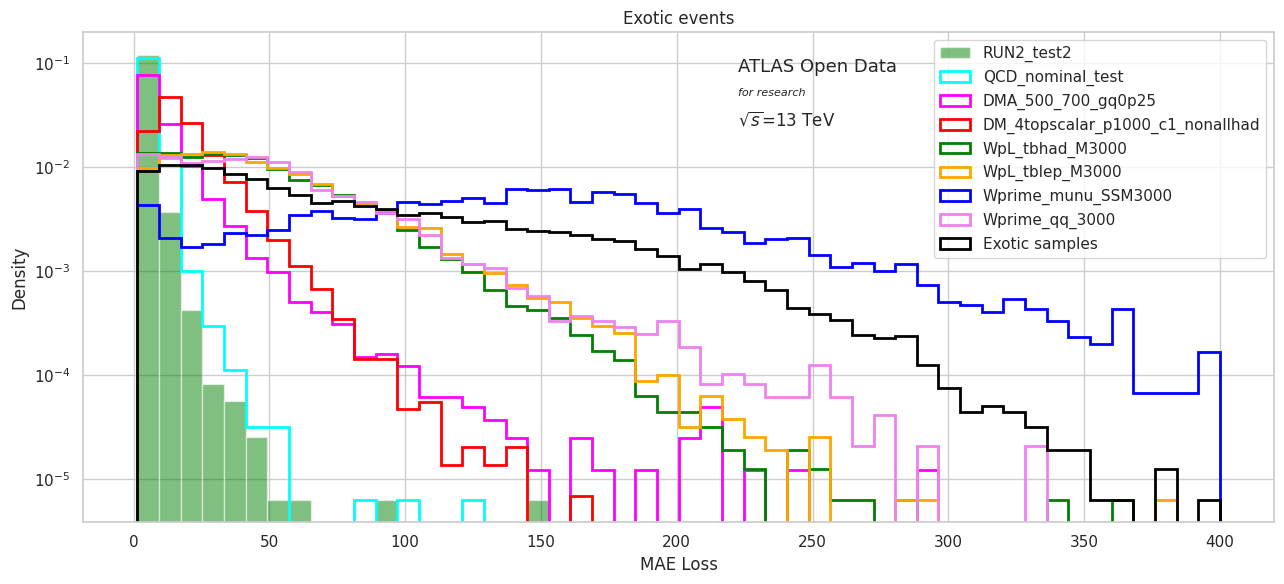

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Assuming losses_dfs dictionary is already created
back_loss = losses_dfs['RUN2_test2']
sig_loss1 = losses_dfs['Higgs_nominal_test']
sig_loss2 = losses_dfs['Top_nominal_test_ttbar']
sig_loss3 = losses_dfs['QCD_nominal_test']
sig_loss4 = losses_dfs['C1N2N1_GGMHinoZh50']
sig_loss5 = losses_dfs['C1N2_WZ _500_100']
sig_loss6 = losses_dfs['DMA_500_700_gq0p25']
sig_loss7 = losses_dfs['DM_4topscalar_p1000_c1_nonallhad']
sig_loss8 = losses_dfs['GG_ttn1_2000_5000_200']
sig_loss9 = losses_dfs['SM4tops']
sig_loss10 = losses_dfs['SM_N2C1p_105_100']
sig_loss11 = losses_dfs['TT_tN1_1200_200']
sig_loss12 = losses_dfs['VBFH125_bb']
sig_loss13 = losses_dfs['WpL_tbhad_M3000']
sig_loss14 = losses_dfs['WpL_tblep_M3000']
sig_loss15 = losses_dfs['Wprime_munu_SSM3000']
sig_loss16 = losses_dfs['Wprime_qq_3000']
sig_loss17 = losses_dfs['Zprimebb3000']
sig_loss18 = losses_dfs['ttH125_ZZ4l_allhad']
sig_loss19 = losses_dfs['ttH125_ZZ4l_semilep']
#exotic_loss =   sig_loss6['mae_loss'] + sig_loss7['mae_loss']  + sig_loss13['mae_loss'] + sig_loss14['mae_loss'] + sig_loss15['mae_loss'] + sig_loss16['mae_loss'] + sig_loss17['mae_loss']
#susy_loss = sig_loss4['mae_loss'] + sig_loss5['mae_loss'] + sig_loss8['mae_loss'] + sig_loss10['mae_loss'] + sig_loss11['mae_loss'] 
exotic_loss =  losses_dfs['Exotic_test']# sig_loss6 + sig_loss7  + sig_loss13 + sig_loss14 + sig_loss15 + sig_loss16 + sig_loss17
susy_loss = losses_dfs['SUSY_test']#sig_loss4 + sig_loss5 + sig_loss8 + sig_loss10 + sig_loss11 


# Find the min and max values for 'mae_loss' across all datasets
min_value_mae_loss = min([np.min(df['mae_loss']) for df in losses_dfs.values()])
max_value_mae_loss = max([np.max(df['mae_loss']) for df in losses_dfs.values()])
max_value_mae_loss = 400  # Set a fixed max value for the histogram range

# Create a new figure for plotting
plt.figure(figsize=(13, 6))

# Plot histograms for all datasets manually
plt.hist(back_loss['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, alpha=0.5, color='green', label='RUN2_test2', density=True)
#plt.hist(sig_loss1['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='blue', histtype='step', linewidth=2, label='Higgs_nominal_test', density=True)
#plt.hist(sig_loss2['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='cyan', histtype='step', linewidth=2, label='ttbar', density=True)
plt.hist(sig_loss3['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='cyan', histtype='step', linewidth=2, label='QCD_nominal_test', density=True)
#plt.hist(sig_loss4['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='magenta', histtype='step', linewidth=2, label='C1N2N1_GGMHinoZh50', density=True)
#plt.hist(sig_loss5['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='orange', histtype='step', linewidth=2, label='C1N2_WZ_500_100', density=True)
plt.hist(sig_loss6['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='magenta', histtype='step', linewidth=2, label='DMA_500_700_gq0p25', density=True)
plt.hist(sig_loss7['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='red', histtype='step', linewidth=2, label='DM_4topscalar_p1000_c1_nonallhad', density=True)
#plt.hist(sig_loss8['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='brown', histtype='step', linewidth=2, label='GG_ttn1_2000_5000_200', density=True)
#plt.hist(sig_loss9['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='orange', histtype='step', linewidth=2, label='SM4tops', density=True)
#plt.hist(sig_loss10['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='blue', histtype='step', linewidth=2, label='SM_N2C1p_105_100', density=True)
#plt.hist(sig_loss11['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='purple', histtype='step', linewidth=2, label='TT_tN1_1200_200', density=True)
#plt.hist(sig_loss12['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='blueviolet', histtype='step', linewidth=2, label='VBFH125_bb', density=True)
plt.hist(sig_loss13['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='green', histtype='step', linewidth=2, label='WpL_tbhad_M3000', density=True)
plt.hist(sig_loss14['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='orange', histtype='step', linewidth=2, label='WpL_tblep_M3000', density=True)
plt.hist(sig_loss15['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='blue', histtype='step', linewidth=2, label='Wprime_munu_SSM3000', density=True)
plt.hist(sig_loss16['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='violet', histtype='step', linewidth=2, label='Wprime_qq_3000', density=True)
#plt.hist(sig_loss17['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='orange', histtype='step', linewidth=2, label='Zprimebb3000', density=True)
#plt.hist(sig_loss18['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='indigo', histtype='step', linewidth=2, label='ttH125_ZZ4l_allhad', density=True)
#plt.hist(sig_loss19['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='red', histtype='step', linewidth=2, label='ttH125_ZZ4l_semilep', density=True)

# Plot the summed exotic and SUSY histograms
plt.hist(exotic_loss['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='black', histtype='step', linewidth=2, label='Exotic samples', density=True)
#plt.hist(susy_loss['mae_loss'], log=True, range=(min_value_mae_loss, max_value_mae_loss), bins=50, color='red', histtype='step', linewidth=2, label='SUSY samples', density=True)
# Labels
plt.xlabel('MAE Loss')
plt.ylabel('Density')
plt.title('Loss Distribution for Multiple Datasets')

# Annotations
plt.text(.55, 0.92, 'ATLAS Open Data', transform=plt.gca().transAxes, fontsize=13)
plt.text(0.55, 0.87, 'for research', transform=plt.gca().transAxes, fontsize=8, style='italic')
plt.text(0.55, 0.81, r'$\sqrt{s}$=13 TeV', transform=plt.gca().transAxes, fontsize=12)# Add title and legend
plt.title("Exotic events")
plt.legend(loc='upper right', bbox_to_anchor=(1., 1))

# Adjust layout and save the plot
plt.tight_layout()
plt.savefig("combined_loss_plot.png")
plt.show()


In [64]:
!pip install umap-learn
!pip install hdbscan
!pip install gower

In [65]:
from re import X
import pandas as pd
import tensorflow as tf

#weight_loss = [1,1,1]

def RecoProb_(Y_true, Y_pred, weight_loss):
    N = 0
    nll_loss = 0
    ml_weights = weight_loss
    Y_true = Y_true
    for ix, wi in enumerate(ml_weights):
        y_pred = Y_pred[:, ix:ix + 1]
        y_true = Y_true[:, ix:ix + 1]
        single_NLL = tf.abs(y_true - y_pred)
        nll_loss += tf.reduce_mean(wi * single_NLL, axis=-1)

    return nll_loss


def process_file(filepath):
    # Read the CSV file
    Dataset = pd.read_csv(filepath, index_col=None, on_bad_lines='skip')
    Dataset_=Dataset
    #weight_loss = [1] * len(branches)

    Dataset.replace(999, 0, inplace=True)
    Dataset.fillna(-99, inplace=True)

    Dataset = Dataset.apply(pd.to_numeric, errors='coerce').dropna()

    
    filter_condition = np.logical_and.reduce([(Dataset[col] != -99) & (Dataset[col] != 0) for col in branch1_columns])
    Dataset = Dataset[filter_condition]
    X_test = Dataset[branches]
    dataset = Dataset



    X_test.loc[:, 'lepton1_pt'] =     X_test['lepton1_pt']/1000
    X_test.loc[:, 'Large_RJet1_pt'] =     X_test['Large_RJet1_pt']/1000
    X_test.loc[:, 'photon1_pt'] =     X_test['photon1_pt']/1000
    X_test.loc[:, 'jet1_mass'] =     X_test['jet1_mass']/1000
    X_test.loc[:, 'jet2_mass'] =     X_test['jet2_mass']/1000
    X_test.loc[:, 'jet3_mass'] =     X_test['jet3_mass']/1000
    X_test.loc[:, 'jet4_mass'] =     X_test['jet4_mass']/1000
    X_test.loc[:, 'jet1_pt'] =     X_test['jet1_pt']/1000
    X_test.loc[:, 'jet2_pt'] =     X_test['jet2_pt']/1000
    X_test.loc[:, 'jet3_pt'] =     X_test['jet3_pt']/1000
    X_test.loc[:, 'jet4_pt'] =     X_test['jet4_pt']/1000
    X_test.loc[:, 'Large_RJet1_mass'] =     X_test['Large_RJet1_mass']/1000
    X_test.loc[:, 'MET_cal1_sumpt']=    X_test['MET_cal1_sumpt']/1000
    X_test.loc[:, 'MET_cal1_px']=    X_test['MET_cal1_px']/10000
    X_test.loc[:, 'MET_cal1_py']=    X_test['MET_cal1_py']/10000
    X_test.loc[:, 'MET_cal1_pz']=    X_test['MET_cal1_pz']/10000
    X_test.loc[:, 'MET1_mpx']=    X_test['MET1_mpx']/1000
    X_test.loc[:, 'MET1_mpy']=    X_test['MET1_mpy']/1000
    X_test.loc[:, 'jet1_width']=    X_test['jet1_width']*100
    X_test.loc[:, 'jet2_width']=    X_test['jet2_width']*100
    X_test.loc[:, 'jet3_width']=    X_test['jet3_width']*100
    X_test.loc[:, 'jet4_width']=    X_test['jet4_width']*100
    X_test.loc[:, 'jet1_EM_frac']=    X_test['jet1_EM_frac']*10
    X_test.loc[:, 'jet2_EM_frac']=    X_test['jet2_EM_frac']*10
    X_test.loc[:, 'jet3_EM_frac']=    X_test['jet3_EM_frac']*10
    X_test.loc[:, 'jet4_EM_frac']=    X_test['jet4_EM_frac']*10
    X_test.loc[:, 'Event_shape1_density'] =     X_test['Event_shape1_density']/1000
    X_test.loc[:, 'photon1_topoetcone20'] =     X_test['photon1_topoetcone20']/1000
    X_test.loc[:, 'photon1_topoetcone40'] =     X_test['photon1_topoetcone40']/1000
    X_test.loc[:, 'MET_cal1_e']=    X_test['MET_cal1_e']/1000
    X_test.loc[:, 'Egamma_cluster1_calE']=    X_test['Egamma_cluster1_calE']/1000
    X_test.loc[:, 'MET1_sumet'] =     X_test['MET1_sumet']/1000
    X_test.loc[:, 'HT']=    X_test['HT']/10000
    X_test.loc[:, 'mT']=    X_test['mT']/10000
    X_test.loc[:, 'mj1j2']=    X_test['mj1j2']/10000
    X_test.loc[:, 'mj1j3']=    X_test['mj1j3']/10000
    X_test.loc[:, 'mj1j4']=    X_test['mj1j4']/10000
    X_test.loc[:, 'mj2j3']=    X_test['mj2j3']/10000
    X_test.loc[:, 'mj2j4']=    X_test['mj2j4']/10000
    X_test.loc[:, 'mj3j4']=    X_test['mj3j4']/10000
    X_test.loc[:, 'nbjets']=    X_test['nbjets']*10
    X_test.loc[:, 'Nleptons']=    X_test['Nleptons']*10
    
    filter_condition = np.all([(X_test[col] != -99) & (X_test[col] != 0) for col in branch1_columns], axis=0)
    X_test = X_test[filter_condition]
    def separate_columns(X_train,columns):
      X_train_sep = X_train[columns].to_numpy()[:, np.newaxis]
      return X_train_sep

    X_test_type1 = separate_columns(X_test, type1_branches)
    X_test_type2 = separate_columns(X_test, type2_branches)
    X_test_type3 = separate_columns(X_test, type3_branches)
    X_test_type4 = separate_columns(X_test, type4_branches)
    X_test_type5 = separate_columns(X_test, type5_branches)
    X_test_type6 = separate_columns(X_test, type6_branches)
    X_test_type7 = separate_columns(X_test, type7_branches)
    X_test_type8 = separate_columns(X_test, type8_branches)
    X_test_type9 = separate_columns(X_test, type9_branches)
    X_test_type10 = separate_columns(X_test, type10_branches)


    X_test_ = separate_columns(X_test, branches)


    decoded = model.predict((X_test_type1,X_test_type2,X_test_type3,X_test_type4,X_test_type5,X_test_type6,X_test_type7,X_test_type8,X_test_type9,X_test_type10))

    decoded_= np.squeeze(decoded)
    X_test__= np.squeeze(X_test_)
    mae_loss = RecoProb_(X_test__, decoded_,weight_loss)
    reconstructed_x = decoded_
    x_test = X_test__
    mae_loss = tf.squeeze(mae_loss)  # Squeeze specific axis if necessary

    print("MAE Loss:", tf.shape(mae_loss))
    # Stack the losses and convert to DataFrame


    losses_df = pd.DataFrame(mae_loss.numpy(), columns=['mae_loss'])

    return losses_df, reconstructed_x, x_test , dataset 

#process_file("back_test.csv")
# List of file paths
file_paths = [

    "/kaggle/input/new-physlite/RUN2_test2.csv",
    "/kaggle/input/new-physlite/RUN2.csv",

]

# Create dictionaries to store the results for each file
losses_dfs = {}
reconstructed_x = {} # Initialize reconstructed_x dictionary
x_test = {} # Initialize X_test_reshaped_ dictionary
dataset ={}
# Process each file and store the result in the dictionary
for path in file_paths:
    # Extract a key for the dictionary based on the file name
    key = path.split('/')[-1].replace('.csv', '')
    #losses_dfs[key] = process_file(path)
    losses_dfs[key], reconstructed_x[key], x_test[key], dataset[key] = process_file(path)

/tmp/ipykernel_78/1474942473.py:23: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  Dataset = pd.read_csv(filepath, index_col=None, on_bad_lines='skip')


4288/4288 ━━━━━━━━━━━━━━━━━━━━ 24s 6ms/step
MAE Loss: tf.Tensor([137189], shape=(1,), dtype=int32)


/tmp/ipykernel_78/1474942473.py:23: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  Dataset = pd.read_csv(filepath, index_col=None, on_bad_lines='skip')


24166/24166 ━━━━━━━━━━━━━━━━━━━━ 118s 5ms/step
MAE Loss: tf.Tensor([773296], shape=(1,), dtype=int32)


In [78]:
# Ensure both DataFrames have the same index
x_test_aligned = dataset['RUN2_test2'].reset_index(drop=True)
losses_aligned = losses_dfs['RUN2_test2']['mae_loss'].reset_index(drop=True)

# Apply filtering condition
df = x_test_aligned[losses_aligned > 30]


df.loc[:, 'UFO_jet1_pt'] = df['UFO_jet1_pt']/1000
df.loc[:, 'UFO_jet2_pt'] = df['UFO_jet2_pt']/1000
df.loc[:, 'lepton1_pt'] = df['lepton1_pt']/1000
df.loc[:, 'lepton2_pt'] = df['lepton2_pt']/1000
df.loc[:, 'lepton3_pt'] = df['lepton3_pt']/1000
df.loc[:, 'lepton4_pt'] = df['lepton4_pt']/1000

df.loc[:, 'Large_RJet1_pt'] = df['Large_RJet1_pt']/1000
df.loc[:, 'photon1_pt'] = df['photon1_pt']/1000
df.loc[:, 'photon2_pt'] = df['photon2_pt']/1000
df.loc[:, 'photon3_pt'] = df['photon3_pt']/1000
df.loc[:, 'photon4_pt'] = df['photon4_pt']/1000

df.loc[:, 'jet1_mass'] = df['jet1_mass']/1000
df.loc[:, 'jet2_mass'] = df['jet2_mass']/1000
df.loc[:, 'jet3_mass'] = df['jet3_mass']/1000
df.loc[:, 'jet4_mass'] = df['jet4_mass']/1000

df.loc[:, 'jet1_pt'] = df['jet1_pt']/1000
df.loc[:, 'jet2_pt'] = df['jet2_pt']/1000
df.loc[:, 'jet3_pt'] = df['jet3_pt']/1000
df.loc[:, 'jet4_pt'] = df['jet4_pt']/1000

df.loc[:, 'UFO_jet1_mass'] = df['UFO_jet1_mass']/1000
df.loc[:, 'UFO_jet2_mass'] = df['UFO_jet2_mass']/1000
df.loc[:, 'Large_RJet1_mass'] = df['Large_RJet1_mass']/1000
df.loc[:, 'MET_cal1_sumpt']=df['MET_cal1_sumpt']/1000
df.loc[:, 'MET_cal2_sumpt']=df['MET_cal2_sumpt']/1000
df.loc[:, 'MET_cal1_px']=df['MET_cal1_px']/10000
df.loc[:, 'MET_cal1_py']=df['MET_cal1_py']/10000
df.loc[:, 'MET_cal1_pz']=df['MET_cal1_pz']/10000
df.loc[:, 'MET_cal2_px']=df['MET_cal2_px']/10000
df.loc[:, 'MET_cal2_py']=df['MET_cal2_py']/10000
df.loc[:, 'MET_cal2_pz']=df['MET_cal2_pz']/10000
df.loc[:, 'MET1_mpx']=df['MET1_mpx']/1000
df.loc[:, 'MET1_mpy']=df['MET1_mpy']/1000
df.loc[:, 'jet1_width']=df['jet1_width']
df.loc[:, 'jet2_width']=df['jet2_width']
df.loc[:, 'jet3_width']=df['jet3_width']
df.loc[:, 'jet4_width']=df['jet4_width']
df.loc[:, 'jet1_EM_frac']=df['jet1_EM_frac']
df.loc[:, 'jet2_EM_frac']=df['jet2_EM_frac']
df.loc[:, 'jet3_EM_frac']=df['jet3_EM_frac']
df.loc[:, 'jet4_EM_frac']=df['jet4_EM_frac']
#df.loc[:, 'Track1_qOverP']=df['Track1_qOverP']*10000
df.loc[:, 'Event_shape1_density'] = df['Event_shape1_density']/1000
df.loc[:, 'photon1_topoetcone20'] = df['photon1_topoetcone20']/1000
df.loc[:, 'photon1_topoetcone40'] = df['photon1_topoetcone40']/1000
df.loc[:, 'MET_cal1_e']=df['MET_cal1_e']/1000
df.loc[:, 'MET_cal2_e']=df['MET_cal2_e']/1000
df.loc[:, 'Egamma_cluster1_calE']=df['Egamma_cluster1_calE']/1000
df.loc[:, 'MET1_sumet'] = df['MET1_sumet']/1000
#df.loc[:, 'pT']=df['pT']/100000
df.loc[:, 'HT']=df['HT']/1000
df.loc[:, 'mj1j2']=df['mj1j2']/1000
df.loc[:, 'mj1j3']=df['mj1j3']/1000
df.loc[:, 'mj1j4']=df['mj1j4']/1000
df.loc[:, 'mj2j3']=df['mj2j3']/1000
df.loc[:, 'mj2j4']=df['mj2j4']/1000
df.loc[:, 'mj3j4']=df['mj3j4']/1000
df.loc[:, 'nbjets']=df['nbjets']
df.loc[:, 'Nleptons']=df['Nleptons']

In [67]:
df

,MET_cal1_px,MET_cal1_py,MET_cal1_pz,MET_cal1_e,MET_cal1_sumpt,MET_cal2_px,MET_cal2_py,MET_cal2_pz,MET_cal2_e,MET_cal2_sumpt,...,lepton1_eta,lepton2_pt,lepton2_phi,lepton2_eta,lepton3_pt,lepton3_phi,lepton3_eta,lepton4_pt,lepton4_phi,lepton4_eta
428,1.629733,0.309908,-4.879627,51.539574,16.590016,-0.009900,-0.009900,-0.009900,-0.099000,-0.099000,...,-1.797200,-0.099000,-99.000000,-99.000000,-0.099,-99.0,-99.0,-0.099,-99.0,-99.0
967,28.337281,74.892500,90.725675,1210.097000,800.751688,-0.009900,-0.009900,-0.009900,-0.099000,-0.099000,...,0.965725,-0.099000,-99.000000,-99.000000,-0.099,-99.0,-99.0,-0.099,-99.0,-99.0
2405,3.076523,14.447708,-11.864301,189.688312,147.881016,1.042775,-0.188934,-0.497641,11.739931,10.615389,...,-0.731286,3.077086,-0.088456,-0.534561,-0.099,-99.0,-99.0,-0.099,-99.0,-99.0
3174,17.059025,7.614680,72.044600,744.273125,186.814875,-0.009900,-0.009900,-0.009900,-0.099000,-0.099000,...,2.059477,-0.099000,-99.000000,-99.000000,-0.099,-99.0,-99.0,-0.099,-99.0,-99.0
3248,-0.484313,-1.270738,5.098650,52.776352,13.615993,-0.009900,-0.009900,-0.009900,-0.099000,-0.099000,...,2.032625,1.803833,1.676656,-0.043402,-0.099,-99.0,-99.0,-0.099,-99.0,-99.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
130368,4.109268,-24.934253,107.405250,1103.386375,252.708297,-0.009900,-0.009900,-0.009900,-0.099000,-0.099000,...,-99.000000,-0.099000,-99.000000,-99.000000,-0.099,-99.0,-99.0,-0.099,-99.0,-99.0
131002,-14.091367,-10.839710,83.555206,854.256250,177.782437,0.260314,0.210148,0.382794,5.102381,3.359352,...,2.255648,-0.099000,-99.000000,-99.000000,-0.099,-99.0,-99.0,-0.099,-99.0,-99.0
131336,2.889176,1.936355,-5.578256,65.847789,34.930453,-0.009900,-0.009900,-0.009900,-0.099000,-0.099000,...,-1.224505,-0.099000,-99.000000,-99.000000,-0.099,-99.0,-99.0,-0.099,-99.0,-99.0
132354,23.839288,-11.182889,-54.215225,602.741625,263.343594,-0.009900,-0.009900,-0.009900,-0.099000,-0.099000,...,-1.474559,-0.099000,-99.000000,-99.000000,-0.099,-99.0,-99.0,-0.099,-99.0,-99.0


In [68]:
"""print(', '.join(f'"{col}"' for col in df.columns))
"""

'print(\', \'.join(f\'"{col}"\' for col in df.columns))\n'

In [79]:
import numpy as np
import pandas as pd
def has_invalid(*args):
    return any(x == -99 for x in args)

# Define your physics functions
def transverse_invariant_mass(pt1, pt2, phi1, phi2):
    if has_invalid(pt1, pt2, phi1, phi2):
        return -99
    delta_phi = np.abs(phi1 - phi2)
    delta_phi = np.minimum(delta_phi, 2 * np.pi - delta_phi)
    m_T_squared = 2 * pt1 * pt2 * (1 - np.cos(delta_phi))
    return np.sqrt(m_T_squared) if m_T_squared > 0 else 0

def di_photon_mass(pt1, eta1, phi1, pt2, eta2, phi2):
    if has_invalid(pt1, eta1, phi1, pt2, eta2, phi2):
        return 0
    delta_eta = eta1 - eta2
    delta_phi = np.abs(phi1 - phi2)
    delta_phi = np.minimum(delta_phi, 2 * np.pi - delta_phi)
    m_gg_squared = 2 * pt1 * pt2 * (np.cosh(delta_eta) - np.cos(delta_phi))
    return np.sqrt(m_gg_squared) if m_gg_squared > 0 else 0

def four_photon_mass(pt1, eta1, phi1, pt2, eta2, phi2, pt3, eta3, phi3, pt4, eta4, phi4):
    if has_invalid(pt1, eta1, phi1, pt2, eta2, phi2, pt3, eta3, phi3, pt4, eta4, phi4):
        return 0
    m_gg1 = di_photon_mass(pt1, eta1, phi1, pt2, eta2, phi2)
    m_gg2 = di_photon_mass(pt3, eta3, phi3, pt4, eta4, phi4)
    m_gggg_squared = m_gg1**2 + m_gg2**2 + 2 * m_gg1 * m_gg2 * (np.cosh(eta1 - eta3) - np.cos(phi1 - phi3))
    return np.sqrt(m_gggg_squared) if m_gggg_squared > 0 else 0

def tri_photon_mass(pt1, eta1, phi1, pt2, eta2, phi2, pt3, eta3, phi3):
    if has_invalid(pt1, eta1, phi1, pt2, eta2, phi2, pt3, eta3, phi3):
        return 0
    m_gg = di_photon_mass(pt1, eta1, phi1, pt2, eta2, phi2)
    m_ggg_squared = m_gg**2 + pt3**2 + 2 * m_gg * pt3 * (np.cosh(eta1 - eta3) - np.cos(phi1 - phi3))
    return np.sqrt(m_ggg_squared) if m_ggg_squared > 0 else 0

def di_mass(pt1, eta1, phi1, pt2, eta2, phi2):
    if has_invalid(pt1, eta1, phi1, pt2, eta2, phi2):
        return 0
    delta_eta = eta1 - eta2
    delta_phi = np.abs(phi1 - phi2)
    delta_phi = np.minimum(delta_phi, 2 * np.pi - delta_phi)
    m_ll_squared = 2 * pt1 * pt2 * (np.cosh(delta_eta) - np.cos(delta_phi))
    return np.sqrt(m_ll_squared) if m_ll_squared > 0 else 0

def tri_mass(pt1, eta1, phi1, pt2, eta2, phi2, pt3, eta3, phi3):
    if has_invalid(pt1, eta1, phi1, pt2, eta2, phi2, pt3, eta3, phi3):
        return 0
    E1 = np.sqrt(pt1**2 + (pt1 * np.sinh(eta1))**2)
    E2 = np.sqrt(pt2**2 + (pt2 * np.sinh(eta2))**2)
    E3 = np.sqrt(pt3**2 + (pt3 * np.sinh(eta3))**2)

    px1, py1, pz1 = pt1 * np.cos(phi1), pt1 * np.sin(phi1), pt1 * np.sinh(eta1)
    px2, py2, pz2 = pt2 * np.cos(phi2), pt2 * np.sin(phi2), pt2 * np.sinh(eta2)
    px3, py3, pz3 = pt3 * np.cos(phi3), pt3 * np.sin(phi3), pt3 * np.sinh(eta3)

    E_total = E1 + E2 + E3
    px_total = px1 + px2 + px3
    py_total = py1 + py2 + py3
    pz_total = pz1 + pz2 + pz3

    mass_3l_squared = E_total**2 - (px_total**2 + py_total**2 + pz_total**2)
    return np.sqrt(mass_3l_squared) if mass_3l_squared > 0 else 0

def four_mass(pt1, eta1, phi1, pt2, eta2, phi2, pt3, eta3, phi3, pt4, eta4, phi4):
    if has_invalid(pt1, eta1, phi1, pt2, eta2, phi2, pt3, eta3, phi3, pt4, eta4, phi4):
        return 0
    def get_energy_and_momentum(pt, eta, phi):
        energy = np.sqrt(pt**2 + (0.000511)**2)  # Electron mass approx.
        px, py, pz = pt * np.cos(phi), pt * np.sin(phi), pt * np.sinh(eta)
        return energy, np.array([px, py, pz])

    E1, p1 = get_energy_and_momentum(pt1, eta1, phi1)
    E2, p2 = get_energy_and_momentum(pt2, eta2, phi2)
    E3, p3 = get_energy_and_momentum(pt3, eta3, phi3)
    E4, p4 = get_energy_and_momentum(pt4, eta4, phi4)

    total_energy = E1 + E2 + E3 + E4
    total_momentum = p1 + p2 + p3 + p4

    M_4l_squared = total_energy**2 - np.dot(total_momentum, total_momentum)
    return np.sqrt(M_4l_squared) if M_4l_squared > 0 else 0

def transverse_mass_with_met(pt, phi, met_pt, met_phi):
    if has_invalid(pt, phi, met_pt, met_phi):
        return 0
    delta_phi = np.abs(phi - met_phi)
    delta_phi = np.minimum(delta_phi, 2 * np.pi - delta_phi)
    m_T_squared = 2 * pt * met_pt * (1 - np.cos(delta_phi))
    return np.sqrt(m_T_squared) if m_T_squared > 0 else 0

# Apply functions to the dataframe
def add_hep_variables(df):
    df["M_gg"] = df.apply(lambda row: di_photon_mass(row['photon1_pt'], row['photon1_eta'], row['photon1_phi'],
                                                     row['photon2_pt'], row['photon2_eta'], row['photon2_phi']), axis=1)

    df["M_ggg"] = df.apply(lambda row: tri_photon_mass(row['photon1_pt'], row['photon1_eta'], row['photon1_phi'],
                                                       row['photon2_pt'], row['photon2_eta'], row['photon2_phi'],
                                                       row['photon3_pt'], row['photon3_eta'], row['photon3_phi']), axis=1)

    df["M_gggg"] = df.apply(lambda row: four_photon_mass(row['photon1_pt'], row['photon1_eta'], row['photon1_phi'],
                                                         row['photon2_pt'], row['photon2_eta'], row['photon2_phi'],
                                                         row['photon3_pt'], row['photon3_eta'], row['photon3_phi'],
                                                         row['photon4_pt'], row['photon4_eta'], row['photon4_phi']), axis=1)

    df["M_ll"] = df.apply(lambda row: di_mass(row['lepton1_pt'], row['lepton1_eta'], row['lepton1_phi'],
                                                     row['lepton2_pt'], row['lepton2_eta'], row['lepton2_phi']), axis=1)

    df["M_lll"] = df.apply(lambda row: tri_mass(row['lepton1_pt'], row['lepton1_eta'], row['lepton1_phi'],
                                                       row['lepton2_pt'], row['lepton2_eta'], row['lepton2_phi'],
                                                       row['lepton3_pt'], row['lepton3_eta'], row['lepton3_phi']), axis=1)

    df["M_llll"] = df.apply(lambda row: four_mass(row['lepton1_pt'], row['lepton1_eta'], row['lepton1_phi'],
                                                         row['lepton2_pt'], row['lepton2_eta'], row['lepton2_phi'],
                                                         row['lepton3_pt'], row['lepton3_eta'], row['lepton3_phi'],
                                                         row['lepton4_pt'], row['lepton4_eta'], row['lepton4_phi']), axis=1)

    df["M_T"] = df.apply(lambda row: transverse_mass_with_met(row['lepton1_pt'], row['lepton1_phi'],
                                                               np.hypot(row['MET1_mpx'], row['MET1_mpy']),
                                                               np.arctan2(row['MET1_mpy'], row['MET1_mpx'])), axis=1)

    df["M_Tgg"] = df.apply(lambda row: transverse_mass_with_met(row['photon1_pt'], row['photon1_phi'],
                                                                 np.hypot(row['MET1_mpx'], row['MET1_mpy']),
                                                                 np.arctan2(row['MET1_mpy'], row['MET1_mpx'])), axis=1)

    df["m_j1j2"] = df.apply(lambda row: di_mass(row['jet1_pt'], row['jet1_eta'], row['jet1_phi'],
                                                            row['jet2_pt'], row['jet2_eta'], row['jet2_phi']), axis=1)

    df["m_j1l"] = df.apply(lambda row: di_mass(row['jet1_pt'], row['jet1_eta'], row['jet1_phi'],
                                                       row['lepton1_pt'], row['lepton1_eta'], row['lepton1_phi']), axis=1)

    df["m_jjj"] = df.apply(lambda row: tri_mass(row['jet1_pt'], row['jet1_eta'], row['jet1_phi'],
                                                       row['jet2_pt'], row['jet2_eta'], row['jet2_phi'],
                                                       row['jet3_pt'], row['jet3_eta'], row['jet3_phi']), axis=1)

    df["m_jjll"] = df.apply(lambda row: four_mass(row['jet1_pt'], row['jet1_eta'], row['jet1_phi'],
                                                         row['jet2_pt'], row['jet2_eta'], row['jet2_phi'],
                                                         row['lepton1_pt'], row['lepton1_eta'], row['lepton1_phi'],
                                                         row['lepton2_pt'], row['lepton2_eta'], row['lepton2_phi']), axis=1)

    return df

# Example usage:
# df = pd.read_csv("your_data.csv")
df = add_hep_variables(df)


/tmp/ipykernel_78/1348352737.py:96: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["M_gg"] = df.apply(lambda row: di_photon_mass(row['photon1_pt'], row['photon1_eta'], row['photon1_phi'],
/tmp/ipykernel_78/1348352737.py:99: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["M_ggg"] = df.apply(lambda row: tri_photon_mass(row['photon1_pt'], row['photon1_eta'], row['photon1_phi'],
/tmp/ipykernel_78/1348352737.py:103: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
T

In [70]:
columns= ["M_gg", "M_ggg", "M_gggg", "M_ll", "M_lll", "M_llll", "M_T", "M_Tgg", "m_j1j2", "m_j1l", "m_jjj", "m_jjll","mj1j2", "mj1j3", "mj1j4", "mj2j3", "mj2j4", "mj3j4"]
#df = df[columns]

/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/tmp/ipykernel_78/1611524669.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['cluster'] = labels


cluster
1    83
0    45
Name: count, dtype: int64


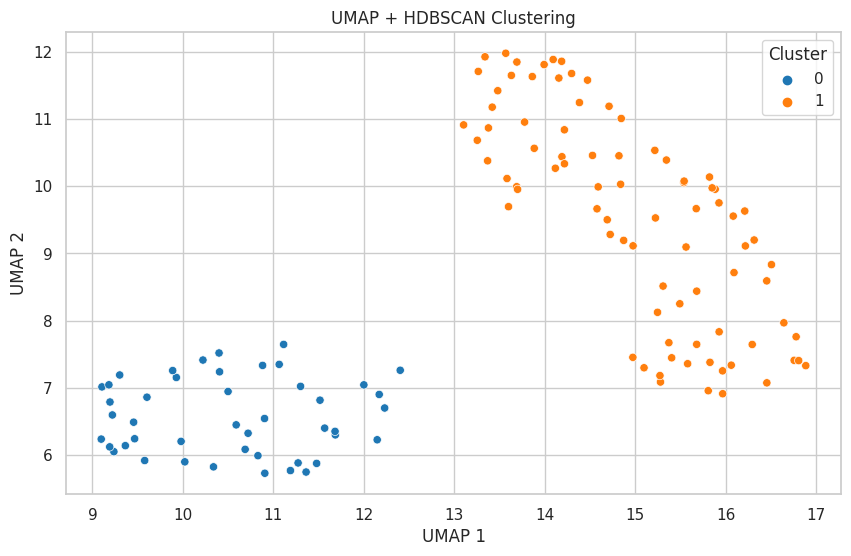

In [71]:

import pandas as pd
import numpy as np
import gower
import umap
import hdbscan

# Step 1: Load your DataFrame
# df = pd.read_csv("your_data.csv")  # Assume you already have `df`

# Step 2: Gower distance for mixed types
gower_dist = gower.gower_matrix(df)

# Step 3: UMAP for dimensionality reduction
reducer = umap.UMAP(
    n_neighbors=10,
    min_dist=0.1,
    n_components=2,
    metric='precomputed',
    random_state=42
)
embedding = reducer.fit_transform(gower_dist)

# Step 4: HDBSCAN clustering
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=5,
    metric='euclidean',
    cluster_selection_method='eom'
)
labels = clusterer.fit_predict(embedding)

# Step 5: Attach cluster labels to original data
df['cluster'] = labels

# Optional: inspect results
print(df['cluster'].value_counts())
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=labels, palette='tab10')
plt.title("UMAP + HDBSCAN Clustering")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Cluster")
plt.show()


In [72]:
"""# Example Python implementation of clustering + profiling pipeline

import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, chi2_contingency
import gower
import umap
import hdbscan


D = gower.gower_matrix(df)  # shape (n_samples, n_samples)

# --- (3) Dimensionality reduction with UMAP ---
# We embed into low-dimensional space (e.g. 2D or 3D) for clustering.
# Use 'precomputed' since we supply our Gower distance matrix.
umap_emb = umap.UMAP(metric='precomputed').fit_transform(D)

# --- (4) Clustering with HDBSCAN ---
# HDBSCAN (density-based) will assign cluster labels; -1 means noise.
clusterer = hdbscan.HDBSCAN(min_cluster_size=5,  # example parameter
                            metric='euclidean')  # embedding space is Euclidean
labels = clusterer.fit_predict(umap_emb)
df['cluster'] = labels
print("Cluster labels assigned (unique):", np.unique(labels))
# Optional: inspect results
print(df['cluster'].value_counts())
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x=embedding[:, 0], y=embedding[:, 1], hue=labels, palette='tab10')
plt.title("UMAP + HDBSCAN Clustering")
plt.xlabel("UMAP 1")
plt.ylabel("UMAP 2")
plt.legend(title="Cluster")
plt.show()"""

'# Example Python implementation of clustering + profiling pipeline\n\nimport numpy as np\nimport pandas as pd\nfrom scipy.stats import ttest_ind, chi2_contingency\nimport gower\nimport umap\nimport hdbscan\n\n\nD = gower.gower_matrix(df)  # shape (n_samples, n_samples)\n\n# --- (3) Dimensionality reduction with UMAP ---\n# We embed into low-dimensional space (e.g. 2D or 3D) for clustering.\n# Use \'precomputed\' since we supply our Gower distance matrix.\numap_emb = umap.UMAP(metric=\'precomputed\').fit_transform(D)\n\n# --- (4) Clustering with HDBSCAN ---\n# HDBSCAN (density-based) will assign cluster labels; -1 means noise.\nclusterer = hdbscan.HDBSCAN(min_cluster_size=5,  # example parameter\n                            metric=\'euclidean\')  # embedding space is Euclidean\nlabels = clusterer.fit_predict(umap_emb)\ndf[\'cluster\'] = labels\nprint("Cluster labels assigned (unique):", np.unique(labels))\n# Optional: inspect results\nprint(df[\'cluster\'].value_counts())\nimport matpl


Cluster 0:
  Top numeric variables (Cohen's d):
    m_j1j2: d = 2.32
    mj1j2: d = 2.32
    m_jjj: d = 2.28
    M_T: d = 1.85
    m_j1l: d = 1.85
  Top categorical variables (Cramér's V):

Cluster 1:
  Top numeric variables (Cohen's d):
    m_j1j2: d = 2.32
    mj1j2: d = 2.32
    m_jjj: d = 2.28
    M_T: d = 1.85
    m_j1l: d = 1.85
  Top categorical variables (Cramér's V):


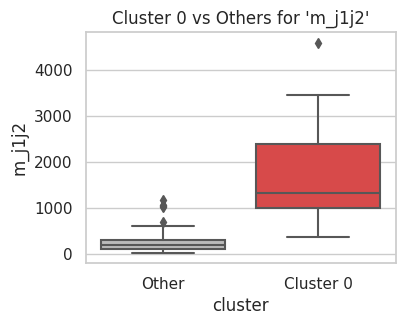

In [73]:


# --- (5) Post-clustering profiling ---
# Identify which variables best separate each cluster from the others.

# Helper function: compute Cohen's d (effect size for mean difference).
def cohen_d(x1, x2):
    # Remove NaNs
    x1 = np.array(x1.dropna())
    x2 = np.array(x2.dropna())
    n1, n2 = len(x1), len(x2)
    if n1 < 2 or n2 < 2:
        return 0.0  # not enough data
    # Compute means and std dev
    m1, m2 = x1.mean(), x2.mean()
    s1, s2 = x1.std(ddof=1), x2.std(ddof=1)
    # Pooled standard deviation
    pooled = np.sqrt(((n1-1)*s1**2 + (n2-1)*s2**2) / (n1+n2-2))
    if pooled == 0:
        return 0.0
    return (m1 - m2) / pooled

# Identify numeric vs categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.drop('cluster')
categorical_cols = df.select_dtypes(exclude=[np.number]).columns

# Prepare a dictionary to hold ranked features per cluster
cluster_rankings = {}

for clust in sorted(df['cluster'].unique()):
    if clust == -1:
        continue  # skip noise
    # Boolean mask for current cluster vs others
    mask = (df['cluster'] == clust)
    mask_other = ~mask
    size_clust = mask.sum()
    size_rest = mask_other.sum()
    if size_clust < 2:
        continue  # skip small clusters
    
    num_scores = []  # (variable, score) for numeric
    cat_scores = []  # (variable, score) for categorical

    # Numeric variables: use Cohen's d
    for col in numeric_cols:
        x1 = df.loc[mask, col]
        x2 = df.loc[mask_other, col]
        d = cohen_d(x1, x2)
        num_scores.append((col, abs(d)))
    # Sort numeric by descending |d|
    num_scores.sort(key=lambda x: x[1], reverse=True)

    # Categorical variables: use Cramér's V from chi-square
    for col in categorical_cols:
        # Build contingency table: (cluster membership) x (category)
        cont = pd.crosstab(df[col], mask)  # index=categories, columns=False/True for other/cluster
        if cont.shape[0] < 2:
            continue  # no variation in category
        # Perform chi-square test
        chi2, p, _, _ = chi2_contingency(cont.values.T)
        N = cont.values.sum()
        # Cramer's V (for 2xk table, it's sqrt(chi2/N))
        V = np.sqrt(chi2 / N) if N > 0 else 0
        cat_scores.append((col, V))
    # Sort categorical by descending V
    cat_scores.sort(key=lambda x: x[1], reverse=True)

    # Store top variables (top 5 of each type, for example)
    cluster_rankings[clust] = {
        'numeric': num_scores[:5],
        'categorical': cat_scores[:5]
    }

# Print ranked variables for each cluster
for clust, ranks in cluster_rankings.items():
    print(f"\nCluster {clust}:")
    print("  Top numeric variables (Cohen's d):")
    for var, score in ranks['numeric']:
        print(f"    {var}: d = {score:.2f}")
    print("  Top categorical variables (Cramér's V):")
    for var, score in ranks['categorical']:
        print(f"    {var}: V = {score:.2f}")

# --- (6) Example visualizations (optional) ---
# For illustration, plot the top feature for cluster 0 if desired:
import matplotlib.pyplot as plt
import seaborn as sns

# Example: boxplot of top numeric feature for cluster 0 vs others
if 0 in cluster_rankings:
    top_num_var = cluster_rankings[0]['numeric'][0][0]
    plt.figure(figsize=(4,3))
    sns.boxplot(x=(df['cluster']==0).astype(int), y=df[top_num_var], 
                palette=["#bbbbbb","#ee3333"])
    plt.xticks([0,1], ["Other", "Cluster 0"])
    plt.title(f"Cluster 0 vs Others for '{top_num_var}'")
    plt.ylabel(top_num_var)
    plt.show()

# Example: bar plot of top categorical feature for cluster 0
if 0 in cluster_rankings and cluster_rankings[0]['categorical']:
    top_cat_var = cluster_rankings[0]['categorical'][0][0]
    plt.figure(figsize=(4,3))
    # Count frequencies in cluster vs others
    df_plot = df.copy()
    df_plot['in_cluster0'] = np.where(df_plot['cluster']==0, 'Cluster 0', 'Others')
    sns.countplot(x=top_cat_var, hue='in_cluster0', data=df_plot)
    plt.title(f"Category counts of '{top_cat_var}'")
    plt.xticks(rotation=45)
    plt.ylabel("Count")
    plt.legend(title="")
    plt.show()


In [74]:
"""import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
# Set plot style
sns.set(style="whitegrid")

# List of mass-related variables
variables = [
    "M_gg", "M_ggg", "M_gggg",
    "M_ll", "M_lll", "M_llll",
    "M_T", "M_Tgg",
    "m_j1j2", "m_j1l", "m_jjj", "m_jjll"
]

# Get unique cluster labels
clusters = sorted(df['cluster'].unique())

# Define mass range for bump hunt
mass_range = (0, 200)

# Plot histograms for each variable per cluster
for var in variables:
    plt.figure(figsize=(12, 6))
    
    for cluster in clusters:
        subset = df[df['cluster'] == cluster]
        # Drop NaNs and apply mass range filter
        filtered = subset[var].dropna()
        filtered = filtered[(filtered >= mass_range[0]) & (filtered <= mass_range[1])]
        
        # Skip cluster if there's no valid data for the variable
        if filtered.empty:
            continue

        sns.histplot(
            filtered,
            label=f'Cluster {cluster}',
            kde=False,
            stat='density',
            bins=50,
            element='step',
            fill=False
        )

    plt.title(f'Histogram of {var} by Cluster (0–2000 GeV)')
    plt.xlabel(f'{var} [GeV]')
    plt.ylabel('Density')
    plt.yscale("log") 
    plt.xlim(mass_range)
    plt.legend()
    plt.tight_layout()
    plt.show()
"""

'import matplotlib.pyplot as plt\nimport seaborn as sns\nimport warnings\nwarnings.filterwarnings("ignore", category=FutureWarning)\n# Set plot style\nsns.set(style="whitegrid")\n\n# List of mass-related variables\nvariables = [\n    "M_gg", "M_ggg", "M_gggg",\n    "M_ll", "M_lll", "M_llll",\n    "M_T", "M_Tgg",\n    "m_j1j2", "m_j1l", "m_jjj", "m_jjll"\n]\n\n# Get unique cluster labels\nclusters = sorted(df[\'cluster\'].unique())\n\n# Define mass range for bump hunt\nmass_range = (0, 200)\n\n# Plot histograms for each variable per cluster\nfor var in variables:\n    plt.figure(figsize=(12, 6))\n    \n    for cluster in clusters:\n        subset = df[df[\'cluster\'] == cluster]\n        # Drop NaNs and apply mass range filter\n        filtered = subset[var].dropna()\n        filtered = filtered[(filtered >= mass_range[0]) & (filtered <= mass_range[1])]\n        \n        # Skip cluster if there\'s no valid data for the variable\n        if filtered.empty:\n            continue\n\n     

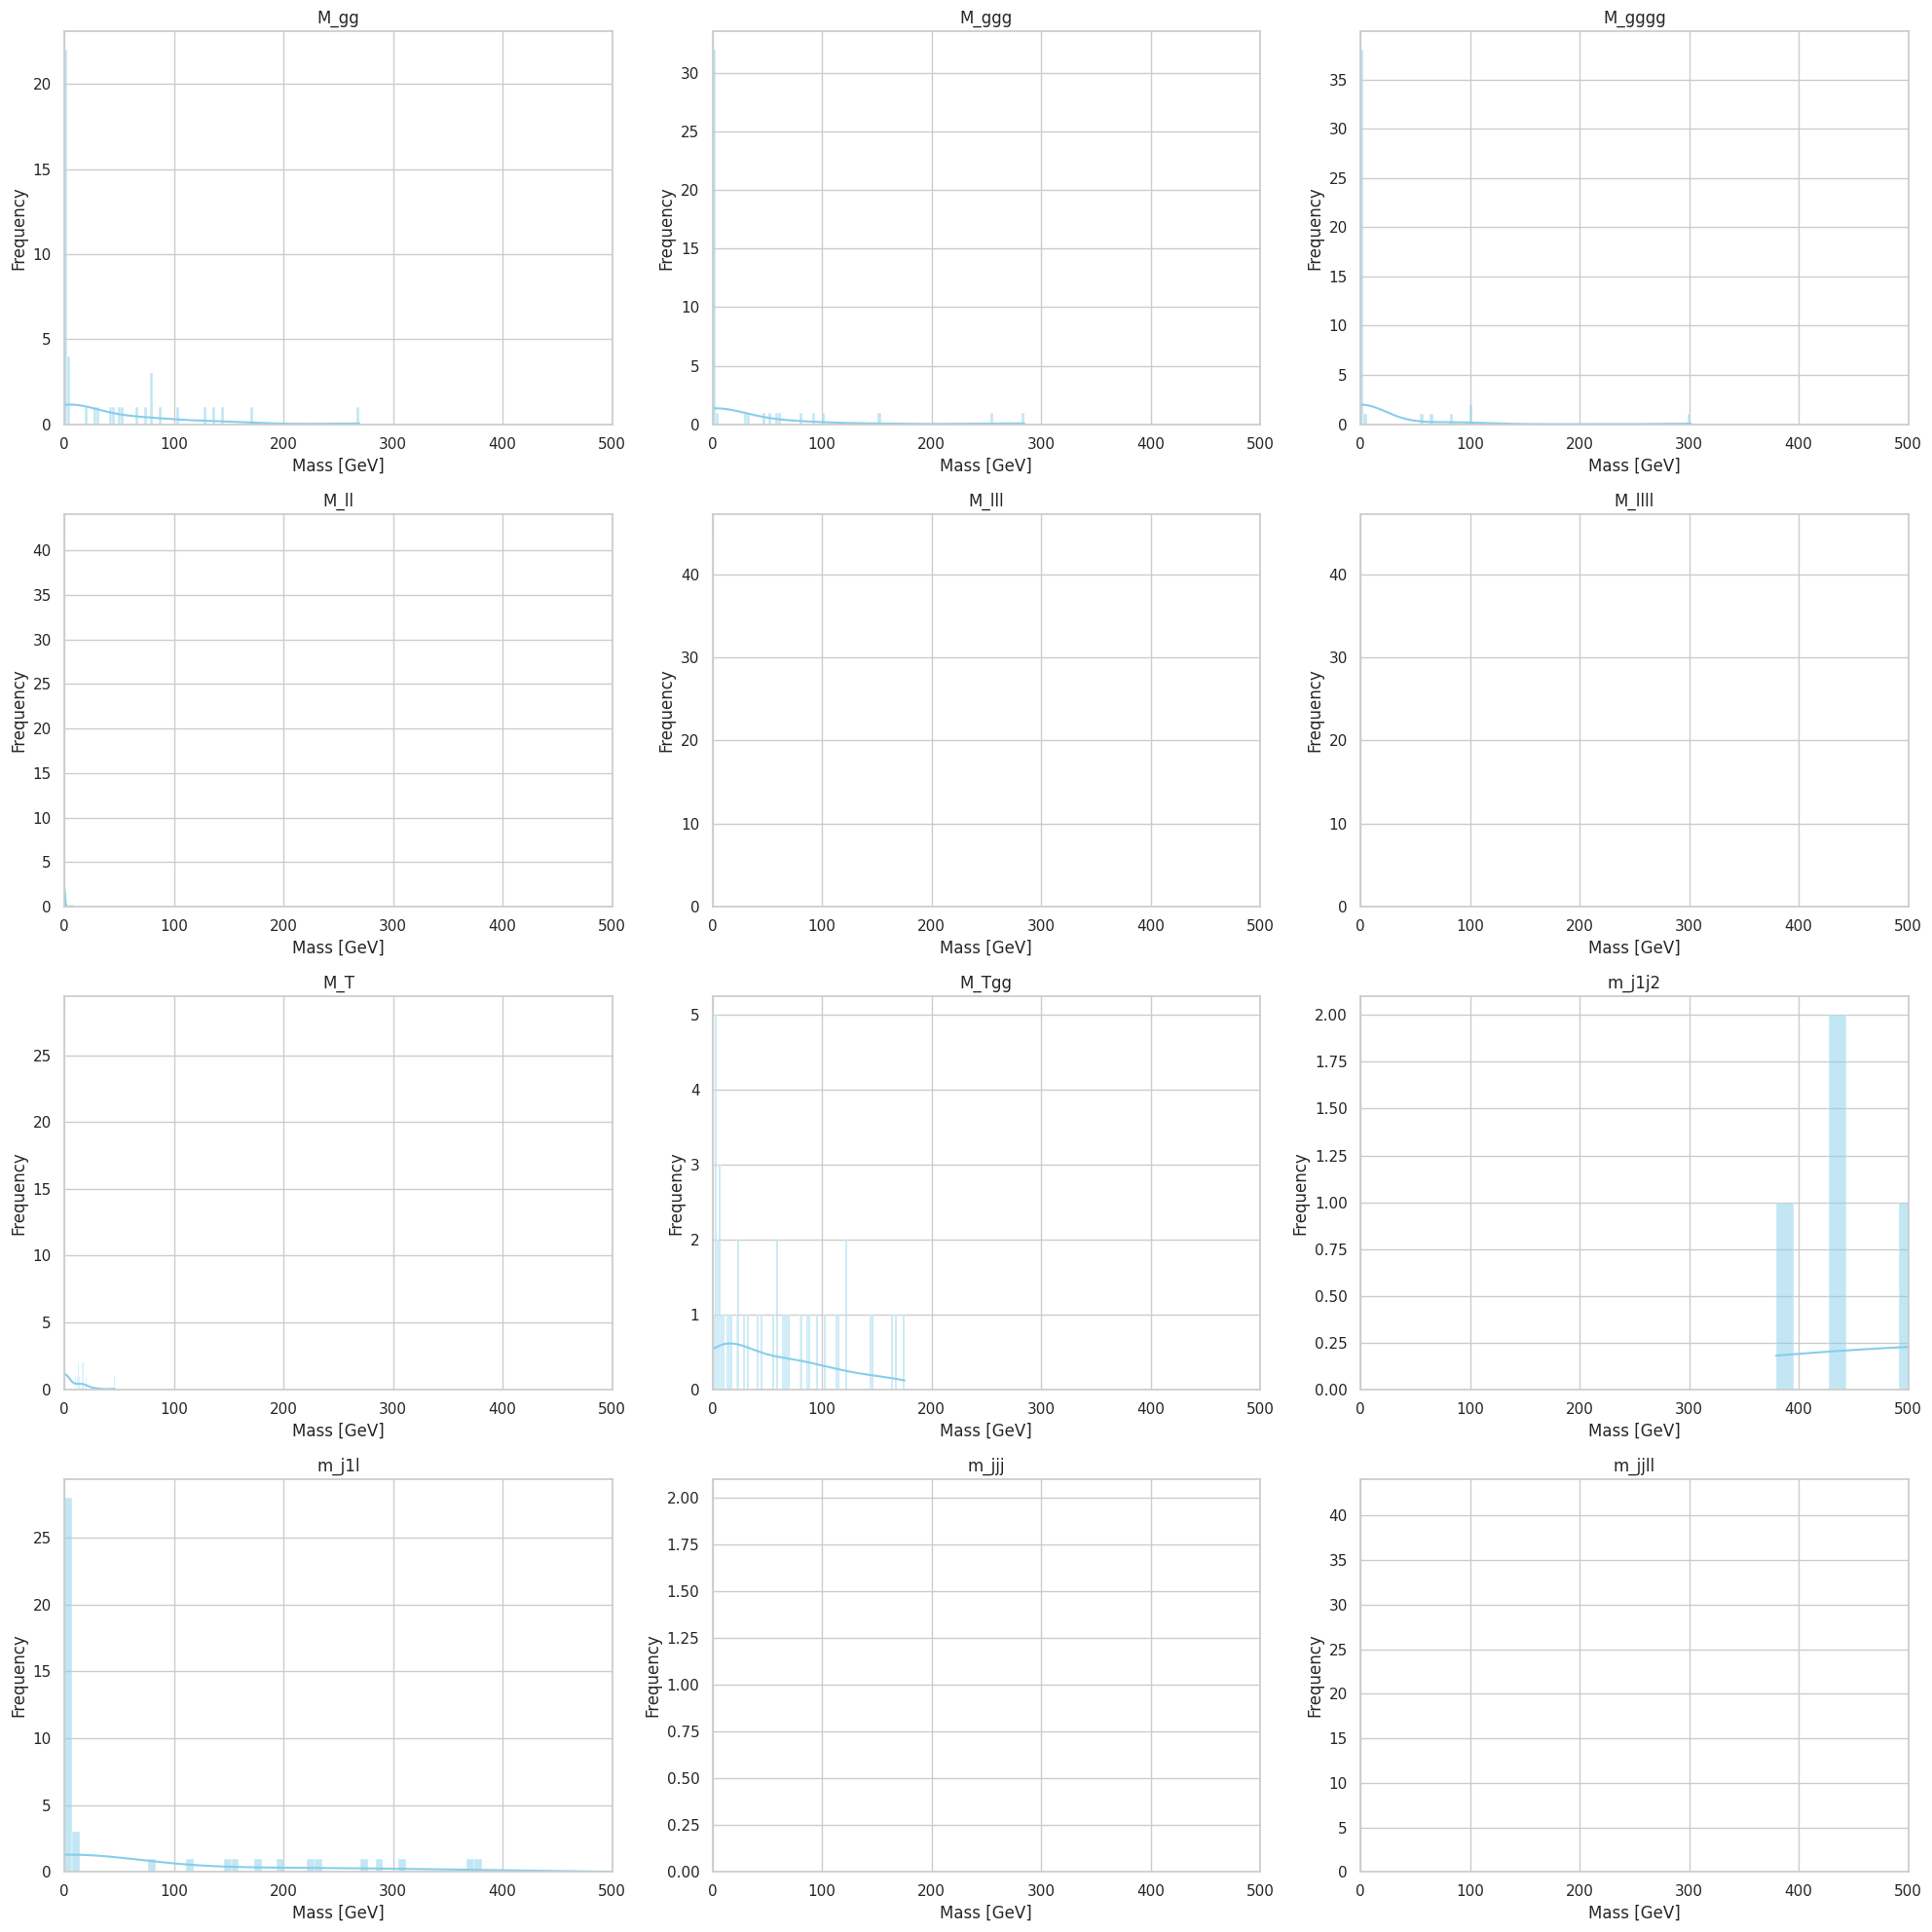

In [75]:
# Ensure both DataFrames have the same index
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


df_ = df[df['cluster'] == 0]
# Set plotting style
sns.set(style="whitegrid")
plt.figure(figsize=(20, 20))



# List of the mass-related variables to plot
mass_columns = [
    "M_gg", "M_ggg", "M_gggg",
    "M_ll", "M_lll", "M_llll",
    "M_T", "M_Tgg",
    "m_j1j2", "m_j1l", "m_jjj", "m_jjll"
]

for i, col in enumerate(mass_columns, 1):
    plt.subplot(4, 3, i)

    # Filter only valid values for this variable (exclude -99)
    data = df_.loc[(df_[col] != -99) & (df_[col] <= 2000), col]

    sns.histplot(data, bins=100, kde=True, color="skyblue")
    plt.title(col)
    plt.xlabel("Mass [GeV]")
    plt.ylabel("Frequency")
    plt.xlim(0, 500)  # Limit x-axis to 0–1000 GeV

plt.tight_layout()
plt.show()

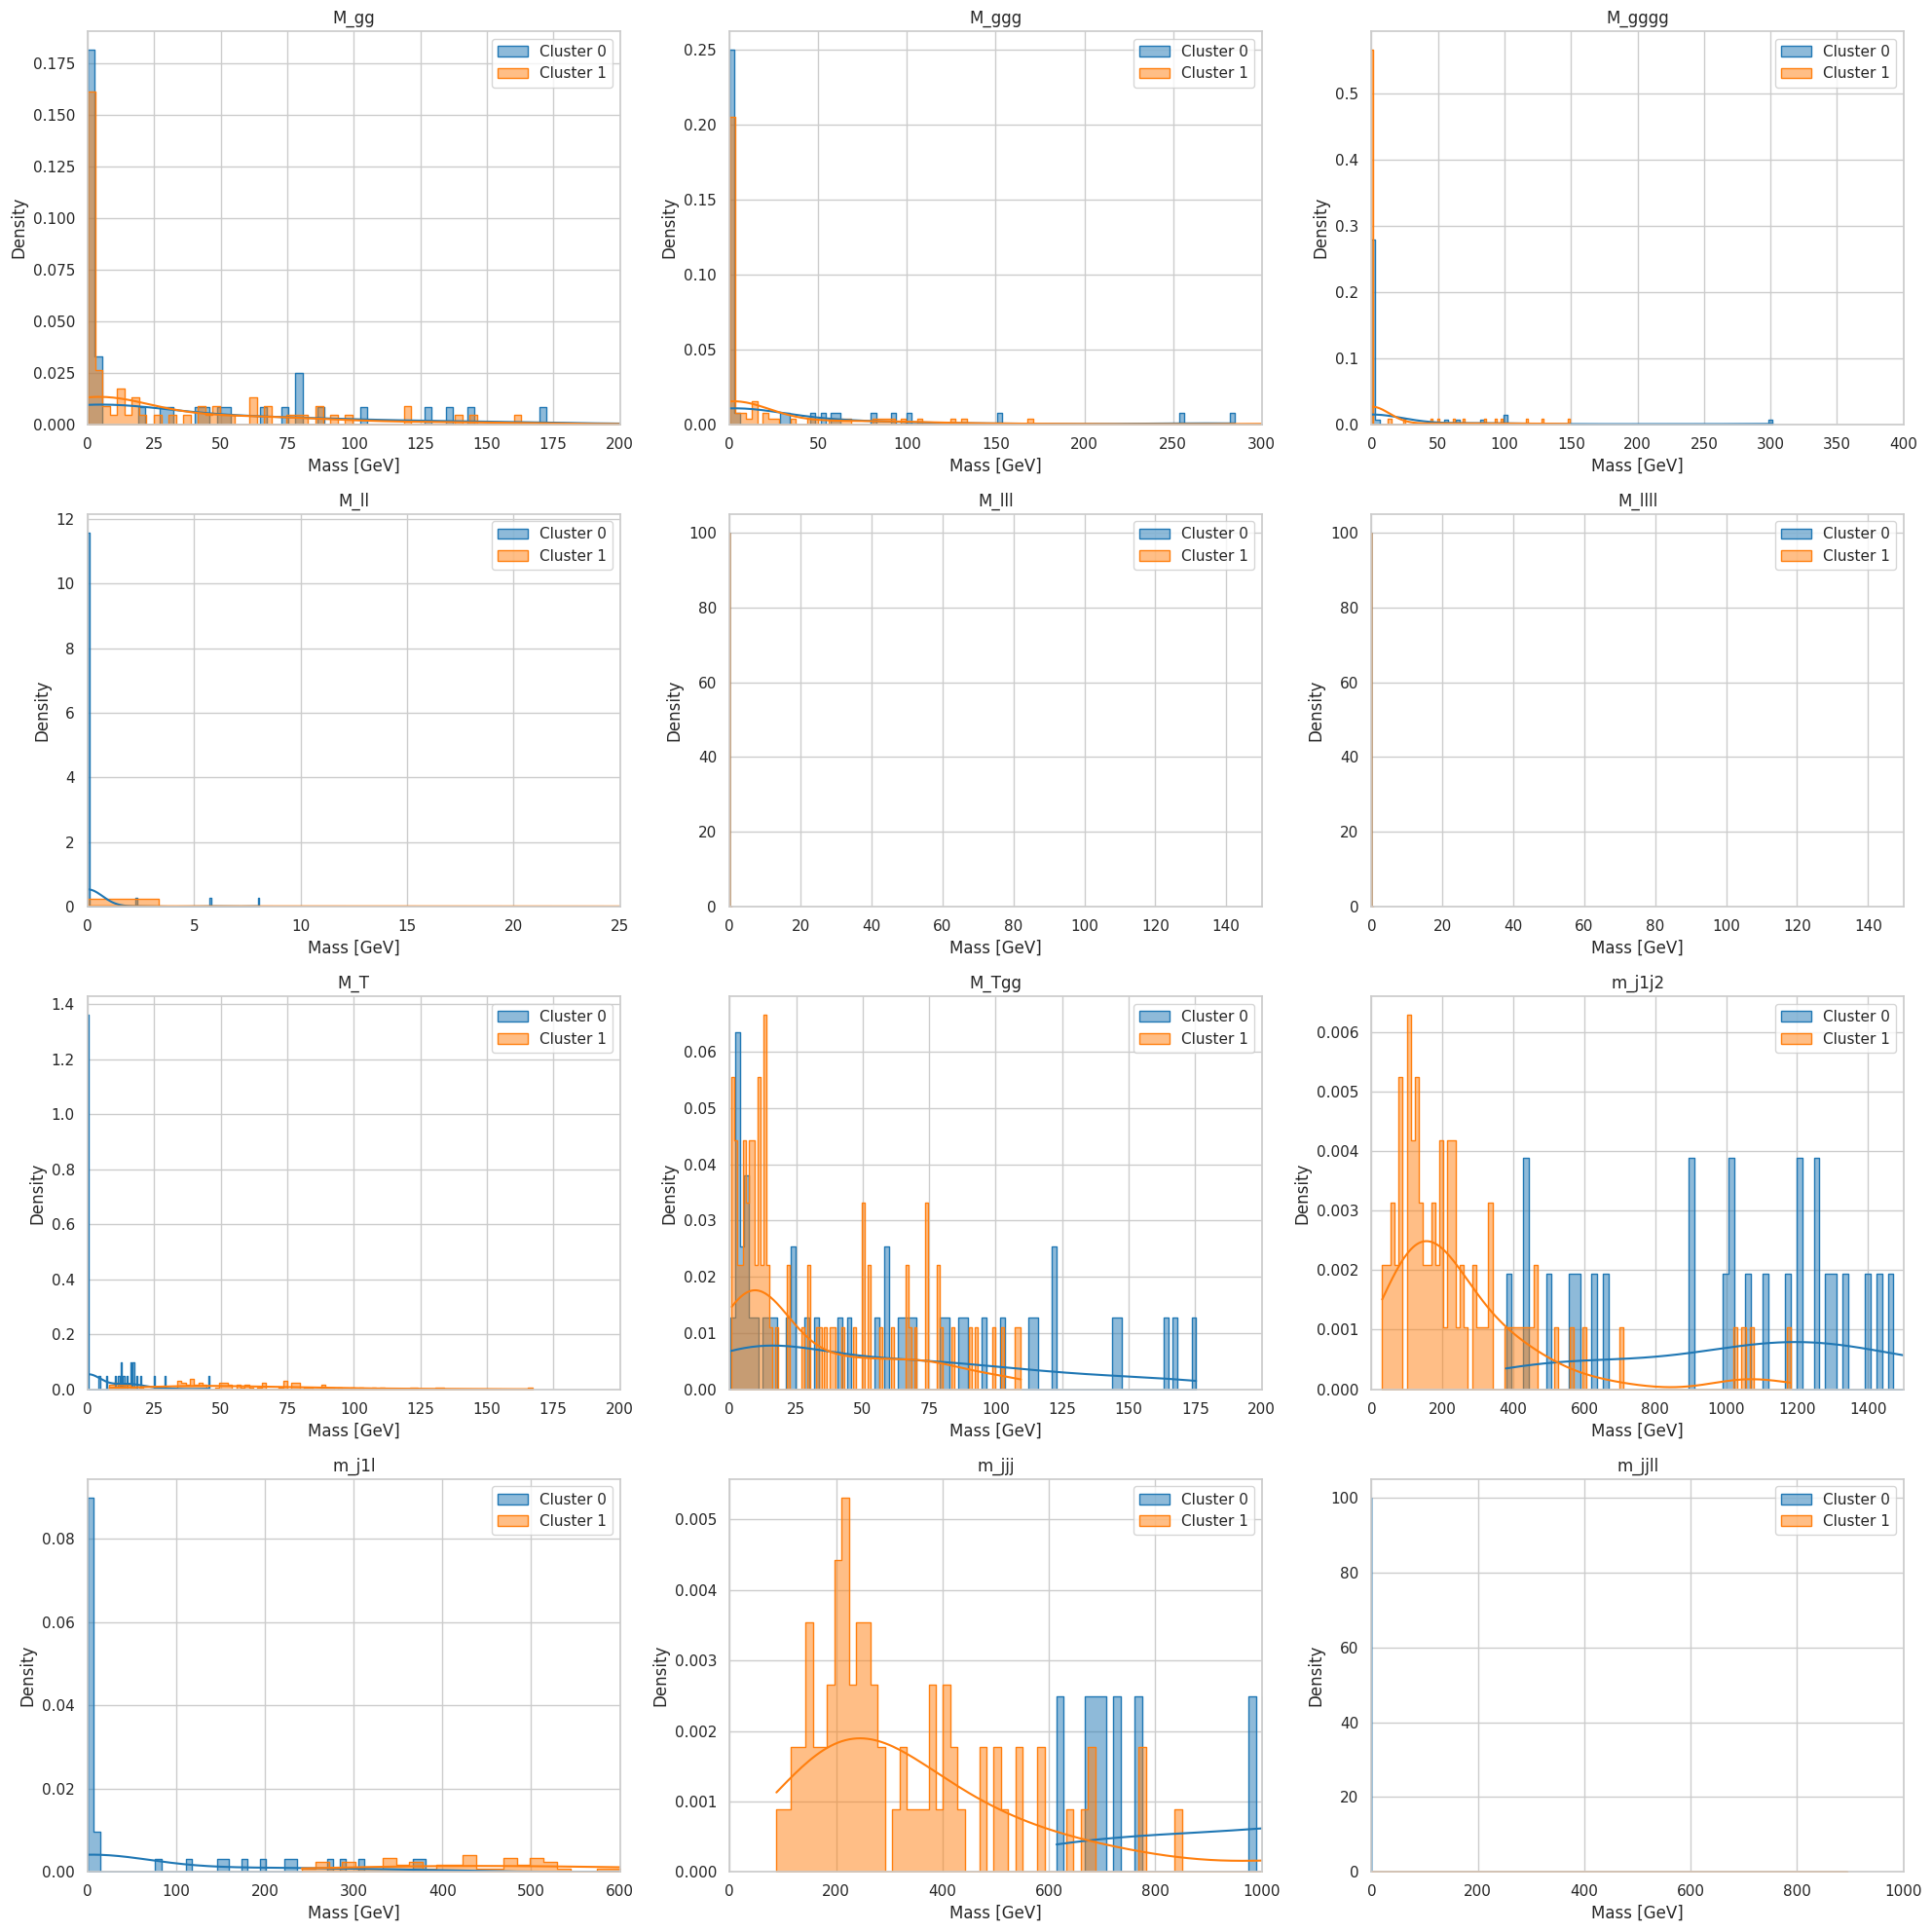

In [76]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)

# Set plotting style
sns.set(style="whitegrid")
plt.figure(figsize=(20, 20))

# List of the mass-related variables to plot
mass_columns = [
    "M_gg", "M_ggg", "M_gggg",
    "M_ll", "M_lll", "M_llll",
    "M_T", "M_Tgg",
    "m_j1j2", "m_j1l", "m_jjj", "m_jjll"
]

# Define custom x-axis limits for each variable
x_ranges = {
    "M_gg": (0, 200),
    "M_ggg": (0, 300),
    "M_gggg": (0, 400),
    "M_ll": (0, 25),
    "M_lll": (0, 150),
    "M_llll": (0, 150),
    "M_T": (0, 200),
    "M_Tgg": (0, 200),
    "m_j1j2": (0, 1500),
    "m_j1l": (0, 600),
    "m_jjj": (0, 1000),
    "m_jjll": (0, 1000)
}

# Unique clusters
clusters = sorted(df['cluster'].unique())
palette = sns.color_palette("tab10", len(clusters))

for i, col in enumerate(mass_columns, 1):
    plt.subplot(4, 3, i)

    for cluster_id, color in zip(clusters, palette):
        cluster_data = df.loc[(df['cluster'] == cluster_id) & 
                              (df[col] != -99) & 
                              (df[col] <= 2000), col]

        sns.histplot(cluster_data, bins=100, kde=True, label=f"Cluster {cluster_id}",
                     color=color, element="step", stat="density", common_norm=False)

    plt.title(col)
    plt.xlabel("Mass [GeV]")
    plt.ylabel("Density")
    plt.xlim(x_ranges.get(col, (0, 500)))  # fallback to (0, 500) if not specified
    plt.legend()

plt.tight_layout()
plt.savefig("cLUSTER.png")
plt.show()



In [80]:
import numpy as np
import pandas as pd

def classify_event(row):
    classification = "Unknown"
    decay_channel = ""

    # Extract features with defaults
    M_gg = row.get('M_gg', 0)
    M_ggg = row.get('M_ggg', 0)
    M_ll = row.get('M_ll', 0)
    M_llll = row.get('M_llll', 0)
    M_T = row.get('M_T', 0)
    MET_magnitude = np.sqrt(row.get('MET1_mpx', 0)**2 + row.get('MET1_mpy', 0)**2)
    Njets = row.get('Njets', 0)
    nbjets = row.get('nbjets', 0)
    Nleptons = row.get('Nleptons', 0)
    Nmuons = row.get('Nmuons', 0)
    Nphotons = row.get('Nphotons', 0)
    mj1j2 = row.get('mj1j2', 0)
    mb1b2 = row.get('mb1b2', 0)

    # --- Standard Model (SM) Decay Channels ---
    if 120 < M_gg < 130 and Nphotons >= 2:
        classification = "Higgs decay"
        decay_channel = "H → γγ"
    elif 120 < M_llll < 130 and Nleptons >= 4:
        classification = "Higgs decay"
        decay_channel = "H → ZZ → 4l"
    elif 120 < M_ll < 130 and MET_magnitude > 30 and Nleptons >= 2:
        classification = "Higgs decay"
        decay_channel = "H → WW → lνlν"
    elif 110 < M_ll < 130 and Nleptons == 2:
        classification = "Higgs decay"
        decay_channel = "H → ττ"
    elif nbjets >= 2 and 110 < mb1b2 < 140:
        classification = "Higgs decay"
        decay_channel = "H → bb"
    elif 80 < M_ll < 100:
        classification = "Z boson decay"
        decay_channel = "Z → ll"
    elif MET_magnitude > 100 and Njets == 0 and Nleptons == 0:
        classification = "Z boson decay"
        decay_channel = "Z → νν"
    elif M_T > 50:
        classification = "W boson decay"
        decay_channel = "W → lν"
    elif 140 < M_ggg < 160 and Nphotons >= 3:
        classification = "SM rare decay"
        decay_channel = "Higgs → 3γ (rare)"
    elif 10 < M_ggg < 150 and Nphotons >= 3 and Nleptons == 0:
        classification = "SM rare process"
        decay_channel = "Triple photon production (γγγ)"
    elif Nphotons == 1 and Njets >= 1 and MET_magnitude < 30:
        classification = "SM background"
        decay_channel = "γ + jet"
    elif 50 < M_ll < 120 and Nleptons == 2 and MET_magnitude < 40:
        classification = "Drell-Yan"
        decay_channel = "Z/γ* → ll"
    elif M_T > 40 and Nleptons == 1 and Njets >= 1 and MET_magnitude > 30:
        classification = "W + jets"
        decay_channel = "W → lν + jets"
    elif Njets >= 4 and nbjets >= 1 and Nleptons >= 1 and MET_magnitude > 40:
        classification = "tt̄ production"
        decay_channel = "tt̄ → Wb Wb → leptons + jets"
    elif Njets >= 2 and nbjets >= 1 and Nleptons == 1 and MET_magnitude > 30:
        classification = "Single top production"
        decay_channel = "t → Wb → lνb"
    elif Njets >= 2 and Nleptons == 0 and Nphotons == 0 and MET_magnitude < 20:
        classification = "QCD multijet"
        decay_channel = "Pure jet production"
    elif 60 < M_ll < 120 and Nleptons == 2 and MET_magnitude > 40 and Njets == 0:
        classification = "Z boson decay"
        decay_channel = "Z → ττ (hadronic)"

    # --- Beyond Standard Model (BSM) Candidates ---
    elif 500 < M_gg < 1000 and Nphotons >= 2:
        classification = "BSM Candidate"
        decay_channel = "Graviton → γγ"
    elif 400 < M_llll < 600 and Nleptons == 4:
        classification = "BSM Candidate"
        decay_channel = "New Scalar → 4l"
    elif 130 < M_gg < 150 and Njets >= 3 and MET_magnitude > 150:
        classification = "BSM Candidate"
        decay_channel = "Heavy Higgs → tt̄"
    elif 200 < M_ll < 300 and Nleptons >= 2 and MET_magnitude > 50:
        classification = "BSM Candidate"
        decay_channel = "Z' → ll"
    elif Njets >= 4 and MET_magnitude > 200:
        classification = "BSM Candidate"
        decay_channel = "Squark/Gluino decay"
    elif Nleptons == 3 and MET_magnitude > 50:
        classification = "BSM Candidate"
        decay_channel = "Trilepton + MET"
    elif M_T > 200 and Nleptons >= 1:
        classification = "BSM Candidate"
        decay_channel = "Chargino decay"
    elif 100 < M_gg < 130 and Nphotons >= 4:
        classification = "BSM Candidate"
        decay_channel = "H → 4γ"
    elif 120 < M_gg < 130 and Nphotons >= 4:
        classification = "BSM Candidate"
        decay_channel = "H → aa → 4γ"
    elif 120 < M_gg < 130 and MET_magnitude > 100:
        classification = "BSM Candidate"
        decay_channel = "H → γγ + MET or invisible"
    elif 120 < M_gg < 130 and Nleptons == 2:
        classification = "BSM Candidate"
        decay_channel = "H → Z'Z' → multiple channels"
    elif MET_magnitude > 150 and Nphotons == 1:
        classification = "Dark Photon + MET Candidate"
        decay_channel = "Dark photon + MET"
    elif 2500 < M_ll < 3500 and Nleptons == 2:
        classification = "Heavy Z' Candidate"
        decay_channel = "Z' → ll"
    elif 2500 < M_T < 3500 and Nleptons == 1 and MET_magnitude > 100:
        classification = "Heavy W' Candidate"
        decay_channel = "W' → lν"
    elif Nleptons == 2 and MET_magnitude > 150 and Njets <= 1:
        classification = "Slepton or Stau Direct Production Candidate"
        decay_channel = "Slepton/Stau pair"
    elif Njets >= 4 and MET_magnitude > 200 and Nleptons >= 1:
        classification = "SUSY Cascade Decay Candidate"
        decay_channel = "Squark/Gluino / Chargino / Higgsino decay"
    elif 300 < M_ggg < 400 and Nphotons >= 3:
        classification = "BSM Candidate"
        decay_channel = "Exotic particle → 3γ"

    # --- Detector-Related Anomalies ---
    elif Nphotons >= 1 and Njets >= 1 and MET_magnitude < 20:
        classification = "Detector Anomaly"
        decay_channel = "Fake Photons"
    elif Nleptons >= 1 and Njets >= 1 and MET_magnitude < 20:
        classification = "Detector Anomaly"
        decay_channel = "Fake Leptons"
    elif MET_magnitude > 100 and Njets == 0 and Nleptons == 0 and Nphotons == 0:
        classification = "Detector Anomaly"
        decay_channel = "Beam Halo"
    elif Nleptons >= 1 and MET_magnitude > 50 and Njets == 0:
        classification = "Detector Anomaly"
        decay_channel = "Cosmic Rays"
    elif Njets >= 1 and MET_magnitude > 100 and Nleptons == 0 and Nphotons == 0:
        classification = "Detector Anomaly"
        decay_channel = "Noise Bursts"
    elif MET_magnitude > 100 and Njets == 0 and Nleptons == 0 and Nphotons == 0:
        classification = "Detector Anomaly"
        decay_channel = "Detector Dead Zones"
    elif Njets >= 5 and Nleptons >= 2 and MET_magnitude > 50:
        classification = "Detector Anomaly"
        decay_channel = "Pile-Up Events"
    elif Nleptons >= 1 and MET_magnitude > 50 and Njets == 0:
        classification = "Detector Anomaly"
        decay_channel = "Timing Anomalies"
    elif Njets >= 1 and MET_magnitude > 100 and Nleptons == 0:
        classification = "Detector Anomaly"
        decay_channel = "Calibration Errors"
    elif Njets == 0 and Nleptons == 0 and Nphotons == 0 and MET_magnitude == 0:
        classification = "Detector Anomaly"
        decay_channel = "Data Corruption"

    return classification, decay_channel

def process_dataframe(df):
    results = []

    for index, row in df.iterrows():
        # Compute invariant masses
        M_gg = di_photon_mass(row['photon1_pt'], row['photon1_eta'], row['photon1_phi'],
                              row['photon2_pt'], row['photon2_eta'], row['photon2_phi'])
        M_ggg = tri_photon_mass(row['photon1_pt'], row['photon1_eta'], row['photon1_phi'],
                                row['photon2_pt'], row['photon2_eta'], row['photon2_phi'],
                                row['photon3_pt'], row['photon3_eta'], row['photon3_phi'])
        M_ll = di_lepton_mass(row['lepton1_pt'], row['lepton1_eta'], row['lepton1_phi'],
                              row['lepton2_pt'], row['lepton2_eta'], row['lepton2_phi'])
        M_llll = four_lepton_mass(row['lepton1_pt'], row['lepton1_eta'], row['lepton1_phi'],
                                  row['lepton2_pt'], row['lepton2_eta'], row['lepton2_phi'],
                                  row['lepton3_pt'], row['lepton3_eta'], row['lepton3_phi'],
                                  row['lepton4_pt'], row['lepton4_eta'], row['lepton4_phi'])
        M_T = transverse_invariant_mass(row['lepton1_pt'], row['lepton2_pt'],
                                        row['lepton1_phi'], row['lepton2_phi'])
        M_Tgg = transverse_invariant_mass(row['photon1_pt'], row['photon2_pt'],
                                          row['photon1_phi'], row['photon2_phi'])

        # Set calculated values into row for use in classification
        row['M_gg'] = M_gg
        row['M_ggg'] = M_ggg
        row['M_ll'] = M_ll
        row['M_llll'] = M_llll
        row['M_T'] = M_T

        # Classify event
        classification, decay_channel = classify_event(row)

        results.append({
            'classification': classification,
            'decay_channel': decay_channel,
            'M_gg': M_gg,
            'M_ggg': M_ggg,
            'M_ll': M_ll,
            'M_llll': M_llll,
            'M_T': M_T,
            'M_Tgg': M_Tgg,
            'MET1_mpx': row['MET1_px'],
            'MET1_mpy': row['MET1_py']
        })

    return pd.DataFrame(results)
anomaldata= process_dataframe(df)
anomaldata

,classification,decay_channel,M_gg,M_ggg,M_ll,M_llll,M_T,M_Tgg,MET1_mpx,MET1_mpy
0,SM background,γ + jet,0.000000,0.000000,0.000000,0,-99.000000,-99.000000,1200.990356,9596.623047
1,Detector Anomaly,Fake Photons,2.851800,0.000000,0.000000,0,-99.000000,2.352127,-9578.889648,-4611.792969
2,Detector Anomaly,Fake Photons,3.870812,0.000000,5.733411,0,5.668553,2.897701,173.178772,-12142.227539
3,Detector Anomaly,Fake Photons,30.920918,37.026095,0.000000,0,-99.000000,6.333921,581.037537,-11709.236328
4,SM background,γ + jet,0.000000,0.000000,63.605427,0,39.355437,-99.000000,-4480.804199,12295.883789
...,...,...,...,...,...,...,...,...,...,...
123,SM rare process,Triple photon production (γγγ),53.399308,61.452470,0.000000,0,-99.000000,48.383773,2903.477539,-6743.472656
124,BSM Candidate,H → 4γ,118.770124,132.930726,0.000000,0,-99.000000,97.778595,-6608.716797,3928.130127
125,Detector Anomaly,Fake Photons,13.713340,0.000000,0.000000,0,-99.000000,3.307907,3472.198730,-14208.666016
126,Detector Anomaly,Fake Photons,5.679110,10.424528,0.000000,0,-99.000000,5.404997,2646.364502,-11397.791016
